# Diabetes Hospital Readmission Prediction: Complete Data Science Project

**Student Name:** Mahnoor Yasir  
**Student ID:** F2023266580  
**Section:** V1  
**Course:** Data Science  
**Instructor:** Sir Abdul Jamil

## Dataset Information

**Dataset Title:** Diabetes 130-US Hospitals for Years 1999-2008  
**Dataset Source:** UCI Machine Learning Repository  
**Dataset Link:** https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008  
**Rows:** 101,766 patient hospital encounters  
**Features:** 47 original features  
**Task Type:** Classification  
**Target Variable:** Readmission within 30 days

This project uses an authentic public medical dataset from the UCI Machine Learning Repository. The dataset contains hospital records of diabetic patients collected over ten years from 130 hospitals and integrated delivery networks. The main goal is to predict whether a diabetic patient is readmitted to the hospital within 30 days.

## Table of Contents

1. Project Setup and Imports  
2. Dataset Loading from UCI Repository  
3. Data Understanding and Metadata  
4. Data Quality Assessment Before Cleaning  
5. Data Preprocessing and Cleaning  
6. Feature Engineering  
7. Data Quality Assessment After Cleaning  
8. Exploratory Data Analysis with 33 Charts  
9. Data Science Questions and Answers  
10. Machine Learning Model Building  
11. Model Evaluation and Confusion Matrix  
12. Final Conclusion and Recommendations

In [1]:
# ============================================================
# 1. INSTALLATION AND IMPORTS
# ============================================================

!pip -q install ucimlrepo

import warnings
warnings.filterwarnings('ignore')

import os
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from ucimlrepo import fetch_ucirepo

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 120)

print('Libraries imported successfully.')

Libraries imported successfully.


In [2]:
# ============================================================
# 2. PROFESSIONAL COLOR THEME FOR ALL CHARTS
# ============================================================

THEME = {
    'background': '#F8FAFC',
    'primary': '#2563EB',
    'secondary': '#7C3AED',
    'accent': '#0891B2',
    'success': '#059669',
    'warning': '#D97706',
    'danger': '#DC2626',
    'dark': '#1E293B',
    'muted': '#64748B',
    'light': '#E2E8F0'
}

PALETTE = ['#2563EB', '#7C3AED', '#0891B2', '#059669', '#D97706', '#DC2626', '#4F46E5', '#0F766E', '#9333EA', '#BE123C']
sns.set_theme(style='whitegrid')
sns.set_palette(PALETTE)
plt.rcParams['figure.facecolor'] = THEME['background']
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = THEME['light']
plt.rcParams['axes.labelcolor'] = THEME['dark']
plt.rcParams['xtick.color'] = THEME['dark']
plt.rcParams['ytick.color'] = THEME['dark']
plt.rcParams['text.color'] = THEME['dark']


def finish_plot(title, xlabel=None, ylabel=None, rotation=0):
    plt.title(title, fontsize=15, fontweight='bold', pad=14)
    if xlabel is not None:
        plt.xlabel(xlabel, fontsize=11)
    if ylabel is not None:
        plt.ylabel(ylabel, fontsize=11)
    plt.xticks(rotation=rotation, ha='right' if rotation else 'center')
    plt.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()

print('Theme configured successfully.')

Theme configured successfully.


In [3]:
# ============================================================
# 3. LOAD DATASET FROM UCI REPOSITORY
# ============================================================

try:
    diabetes = fetch_ucirepo(id=296)
    X = diabetes.data.features.copy()
    y = diabetes.data.targets.copy()
    df = pd.concat([X, y], axis=1)
    print('Dataset loaded using ucimlrepo.')
except Exception as e:
    print('ucimlrepo loading failed. Trying direct UCI zip download...')
    url = 'https://archive.ics.uci.edu/static/public/296/diabetes+130-us+hospitals+for+years+1999-2008.zip'
    zip_path = '/content/diabetes_uci.zip'
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('/content/diabetes_uci')
    csv_files = list(Path('/content/diabetes_uci').rglob('*.csv'))
    data_file = [f for f in csv_files if 'diabetic_data' in f.name][0]
    df = pd.read_csv(data_file)
    print('Dataset loaded using direct UCI download.')

print('Dataset shape:', df.shape)
display(df.head())

Dataset loaded using ucimlrepo.
Dataset shape: (101766, 48)


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
# ============================================================
# 4. BASIC DATA UNDERSTANDING
# ============================================================

print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
print('\nColumn names:')
print(df.columns.tolist())

print('\nData types:')
display(df.dtypes.value_counts())

print('\nTarget distribution:')
display(df['readmitted'].value_counts(dropna=False))

print('\nDataset information:')
df.info()

Rows: 101766
Columns: 48

Column names:
['race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Data types:


,count
object,37
int64,11



Target distribution:


,count
readmitted,
NO,54864
>30,35545
<30,11357



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      99493 non-null   object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   weight                    3197 non-null    object
 4   admission_type_id         101766 non-null  int64 
 5   discharge_disposition_id  101766 non-null  int64 
 6   admission_source_id       101766 non-null  int64 
 7   time_in_hospital          101766 non-null  int64 
 8   payer_code                61510 non-null   object
 9   medical_specialty         51817 non-null   object
 10  num_lab_procedures        101766 non-null  int64 
 11  num_procedures            101766 non-null  int64 
 12  num_medications           101766 non-null  int64 
 13  number_outpatient         101766 non-

In [5]:
# ============================================================
# 5. DATA QUALITY BEFORE CLEANING
# ============================================================

raw_df = df.copy()
raw_missing = raw_df.replace('?', np.nan).isna().sum().sort_values(ascending=False)
raw_missing_percent = (raw_missing / len(raw_df) * 100).round(2)
missing_before = pd.DataFrame({
    'Missing_Count': raw_missing,
    'Missing_Percentage': raw_missing_percent
})

print('Missing values before cleaning:')
display(missing_before[missing_before['Missing_Count'] > 0].head(30))

print('Duplicate rows before cleaning:', raw_df.duplicated().sum())
print('Original shape:', raw_df.shape)

Missing values before cleaning:


,Missing_Count,Missing_Percentage
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


Duplicate rows before cleaning: 0
Original shape: (101766, 48)


## Data Preprocessing Plan

The dataset contains symbols such as `?`, high-cardinality categorical columns, ID columns, and several medical categorical fields. The preprocessing steps below clean the dataset and prepare it for visualization and machine learning.

Main cleaning steps:

1. Replace `?` values with missing values.  
2. Remove duplicate records.  
3. Remove invalid gender records.  
4. Create a binary target variable for 30-day readmission.  
5. Engineer useful features such as age midpoint, total previous visits, and medication change count.  
6. Keep useful columns for modeling and avoid direct patient identifiers.  
7. Handle missing numeric and categorical values using pipelines.

## Data Cleaning and Preprocessing

The cleaning process is divided into separate cells so each step can be executed and understood clearly.

In [6]:
# 6.1 Create a working copy and standardize missing values/column names
clean_df = raw_df.copy()
clean_df = clean_df.replace('?', np.nan)
clean_df.columns = clean_df.columns.str.strip().str.replace(' ', '_')

print('Working copy created.')
print('Shape after copying:', clean_df.shape)


Working copy created.
Shape after copying: (101766, 48)


In [7]:
# 6.2 Remove duplicate rows
before_rows = clean_df.shape[0]
clean_df = clean_df.drop_duplicates()
after_rows = clean_df.shape[0]

print('Duplicate rows removed:', before_rows - after_rows)
print('Shape after duplicate removal:', clean_df.shape)


Duplicate rows removed: 0
Shape after duplicate removal: (101766, 48)


In [8]:
# 6.3 Remove invalid gender rows
if 'gender' in clean_df.columns:
    before_rows = clean_df.shape[0]
    clean_df = clean_df[clean_df['gender'] != 'Unknown/Invalid']
    after_rows = clean_df.shape[0]
    print('Invalid gender rows removed:', before_rows - after_rows)
else:
    print('Gender column not found.')

print('Shape after gender cleaning:', clean_df.shape)


Invalid gender rows removed: 3
Shape after gender cleaning: (101763, 48)


In [9]:
# 6.4 Create binary target variable for 30-day readmission
clean_df['readmitted_30_days'] = (clean_df['readmitted'] == '<30').astype(int)

print('Target variable created: readmitted_30_days')
display(clean_df['readmitted_30_days'].value_counts().to_frame('Count'))


Target variable created: readmitted_30_days


,Count
readmitted_30_days,
0,90406
1,11357


In [10]:
# 6.5 Feature engineering: age midpoint

def age_midpoint(age_value):
    try:
        value = str(age_value).replace('[', '').replace(')', '')
        low, high = value.split('-')
        return (int(low) + int(high)) / 2
    except Exception:
        return np.nan

clean_df['age_midpoint'] = clean_df['age'].apply(age_midpoint)

display(clean_df[['age', 'age_midpoint']].head())


,age,age_midpoint
0,[0-10),5.0
1,[10-20),15.0
2,[20-30),25.0
3,[30-40),35.0
4,[40-50),45.0


In [11]:
# 6.6 Feature engineering: total previous hospital/medical visits
visit_cols = ['number_outpatient', 'number_emergency', 'number_inpatient']
for col in visit_cols:
    if col not in clean_df.columns:
        clean_df[col] = 0

clean_df['total_previous_visits'] = clean_df[visit_cols].sum(axis=1)

display(clean_df[visit_cols + ['total_previous_visits']].head())


,number_outpatient,number_emergency,number_inpatient,total_previous_visits
0,0,0,0,0
1,0,0,0,0
2,2,0,1,3
3,0,0,0,0
4,0,0,0,0


In [12]:
# 6.7 Feature engineering: medication change count
medication_columns = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]
medication_columns = [c for c in medication_columns if c in clean_df.columns]

clean_df['medication_change_count'] = clean_df[medication_columns].apply(
    lambda row: sum(row.isin(['Up', 'Down'])), axis=1
)

print('Medication columns used:', len(medication_columns))
display(clean_df[['medication_change_count']].describe())


Medication columns used: 23


,medication_change_count
count,101763.000000
mean,0.287452
std,0.487531
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,4.000000


In [13]:
# 6.8 Feature engineering: primary diagnosis group

def diagnosis_group(code):
    if pd.isna(code):
        return 'Unknown'
    code = str(code)
    if code.startswith('V') or code.startswith('E'):
        return 'External or Supplementary'
    try:
        value = float(code)
        if 390 <= value <= 459 or value == 785:
            return 'Circulatory'
        elif 460 <= value <= 519 or value == 786:
            return 'Respiratory'
        elif 520 <= value <= 579 or value == 787:
            return 'Digestive'
        elif value == 250:
            return 'Diabetes'
        elif 800 <= value <= 999:
            return 'Injury'
        elif 710 <= value <= 739:
            return 'Musculoskeletal'
        elif 580 <= value <= 629 or value == 788:
            return 'Genitourinary'
        elif 140 <= value <= 239:
            return 'Neoplasms'
        else:
            return 'Other'
    except Exception:
        return 'Other'

if 'diag_1' in clean_df.columns:
    clean_df['primary_diagnosis_group'] = clean_df['diag_1'].apply(diagnosis_group)
else:
    clean_df['primary_diagnosis_group'] = 'Unknown'

display(clean_df['primary_diagnosis_group'].value_counts().to_frame('Count'))


,Count
primary_diagnosis_group,
Circulatory,30436
Other,25049
Respiratory,14423
Digestive,9475
Injury,6972
Genitourinary,5117
Musculoskeletal,4957
Neoplasms,3433
External or Supplementary,1645


In [ ]:
# 6.9 Final cleaned dataset preview
print('Cleaned dataset shape:', clean_df.shape)
display(clean_df.head())


In [14]:
# ============================================================
# 7. DATA QUALITY AFTER CLEANING
# ============================================================

clean_missing = clean_df.isna().sum().sort_values(ascending=False)
clean_missing_percent = (clean_missing / len(clean_df) * 100).round(2)
missing_after = pd.DataFrame({
    'Missing_Count': clean_missing,
    'Missing_Percentage': clean_missing_percent
})

print('Missing values after basic cleaning:')
display(missing_after[missing_after['Missing_Count'] > 0].head(30))

print('Duplicate rows after cleaning:', clean_df.duplicated().sum())
print('Rows after cleaning:', clean_df.shape[0])
print('Columns after feature engineering:', clean_df.shape[1])

Missing values after basic cleaning:


,Missing_Count,Missing_Percentage
weight,98566,96.86
max_glu_serum,96417,94.75
A1Cresult,84745,83.28
medical_specialty,49947,49.08
payer_code,40255,39.56
race,2271,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


Duplicate rows after cleaning: 0
Rows after cleaning: 101763
Columns after feature engineering: 53


# Exploratory Data Analysis

This section contains 33 non-overlapping visualizations. Each chart is created separately with a consistent color theme and proper layout settings.

# Exploratory Data Analysis Charts

Each chart is placed in a separate code cell to avoid overlap and make the notebook easier to run and understand.

## CHART 1: Target distribution

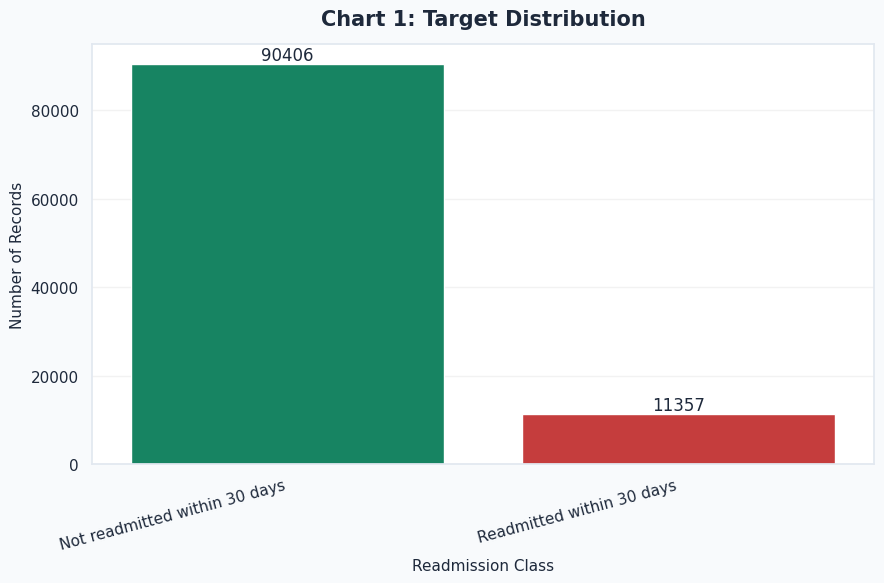

In [15]:
# CHART 1: Target distribution
plt.figure(figsize=(9, 6))
ax = sns.countplot(data=clean_df, x='readmitted_30_days', palette=[THEME['success'], THEME['danger']])
ax.set_xticklabels(['Not readmitted within 30 days', 'Readmitted within 30 days'])
for container in ax.containers:
    ax.bar_label(container)
finish_plot('Chart 1: Target Distribution', 'Readmission Class', 'Number of Records', 15)


## CHART 2: Original readmission categories

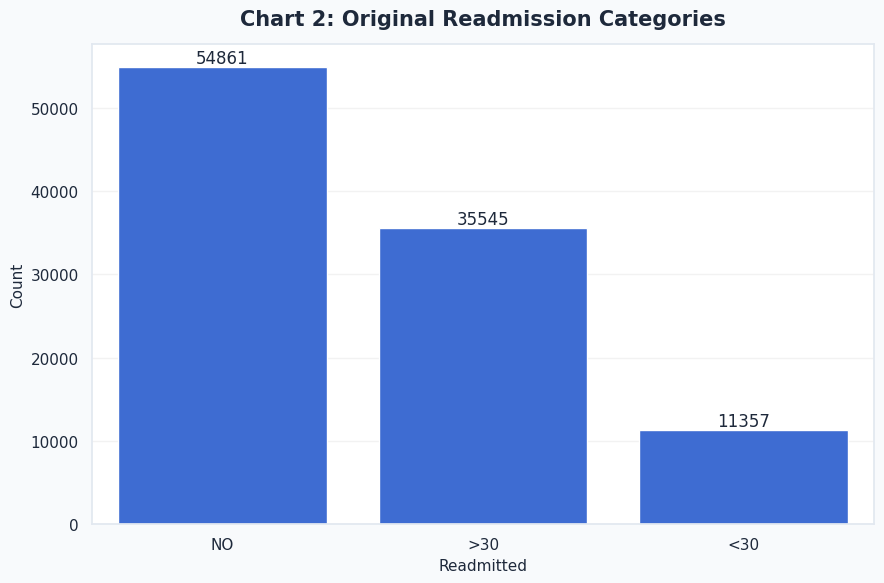

In [16]:
# CHART 2: Original readmission categories
plt.figure(figsize=(9, 6))
ax = sns.countplot(data=clean_df, x='readmitted', order=clean_df['readmitted'].value_counts().index)
for container in ax.containers:
    ax.bar_label(container)
finish_plot('Chart 2: Original Readmission Categories', 'Readmitted', 'Count')


## CHART 3: Race distribution

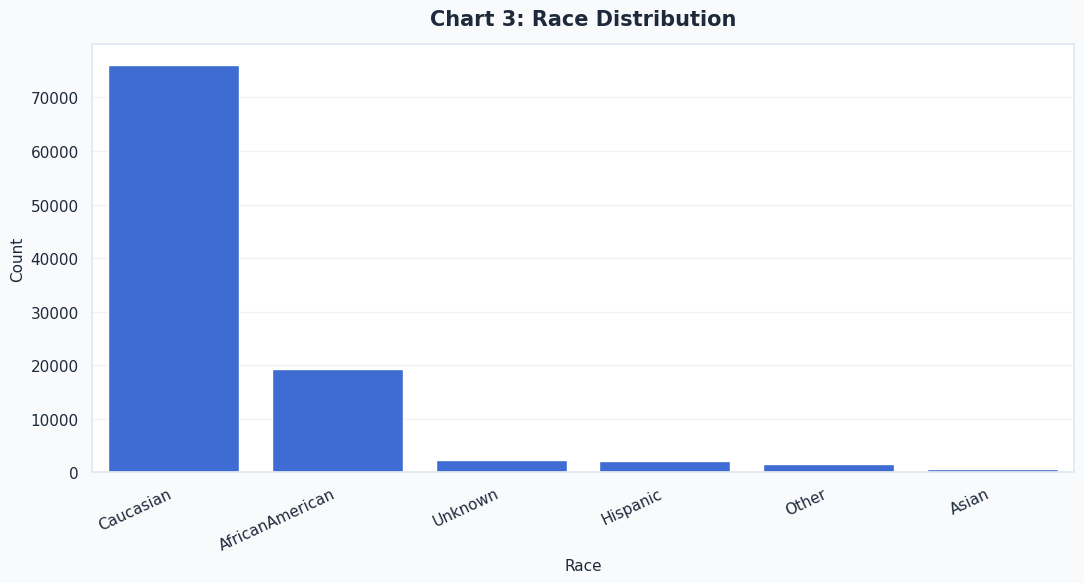

In [17]:
# CHART 3: Race distribution
plt.figure(figsize=(11, 6))
order = clean_df['race'].fillna('Unknown').value_counts().index
ax = sns.countplot(data=clean_df.fillna({'race':'Unknown'}), x='race', order=order)
finish_plot('Chart 3: Race Distribution', 'Race', 'Count', 25)


## CHART 4: Gender distribution

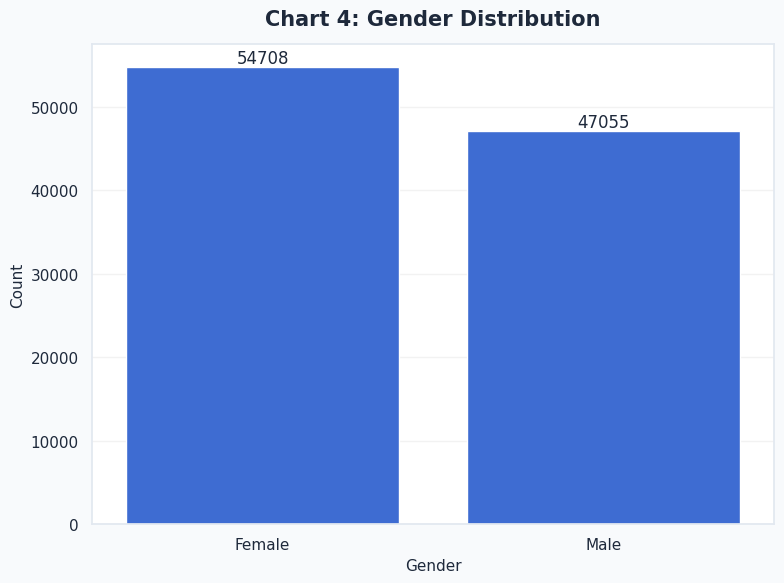

In [18]:
# CHART 4: Gender distribution
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=clean_df, x='gender', order=clean_df['gender'].value_counts().index)
for container in ax.containers:
    ax.bar_label(container)
finish_plot('Chart 4: Gender Distribution', 'Gender', 'Count')


## CHART 5: Age group distribution

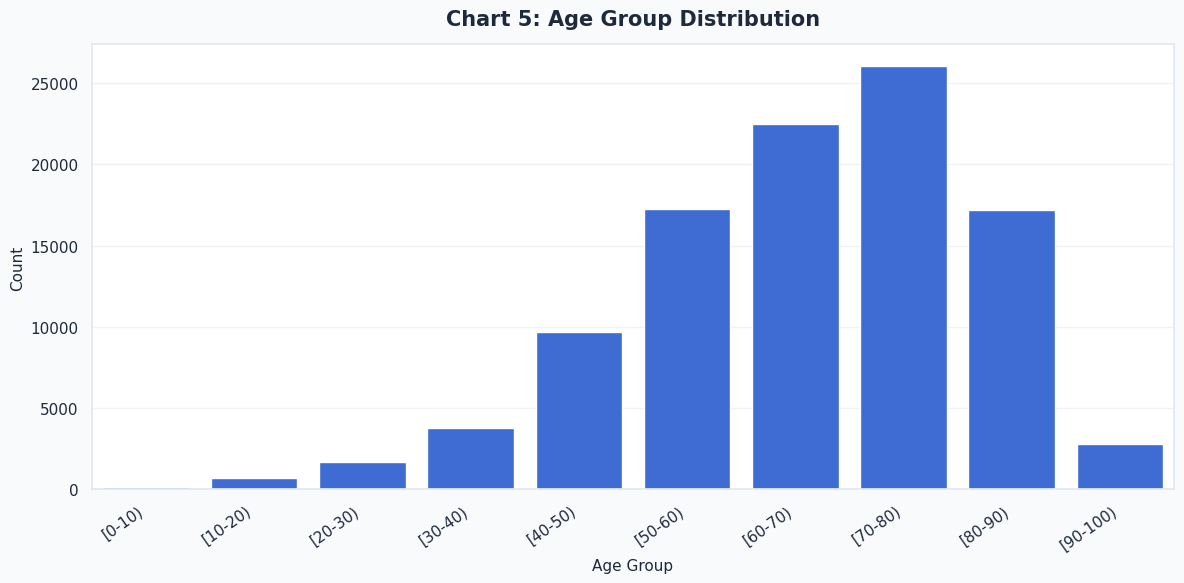

In [19]:
# CHART 5: Age group distribution
plt.figure(figsize=(12, 6))
age_order = sorted(clean_df['age'].dropna().unique())
sns.countplot(data=clean_df, x='age', order=age_order)
finish_plot('Chart 5: Age Group Distribution', 'Age Group', 'Count', 35)


## CHART 6: Age midpoint distribution

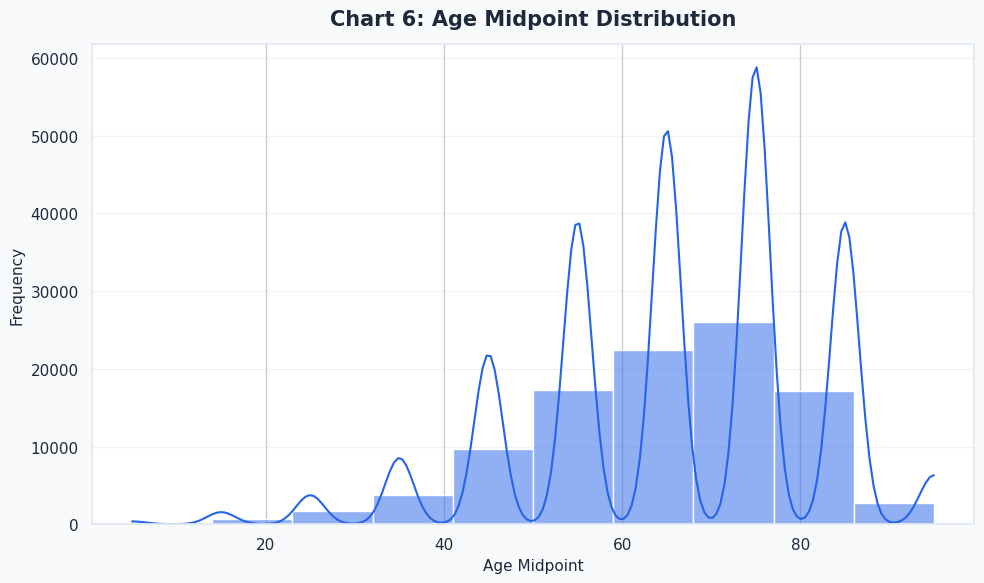

In [20]:
# CHART 6: Age midpoint distribution
plt.figure(figsize=(10, 6))
sns.histplot(clean_df['age_midpoint'], bins=10, kde=True, color=THEME['primary'])
finish_plot('Chart 6: Age Midpoint Distribution', 'Age Midpoint', 'Frequency')


## CHART 7: Time in hospital distribution

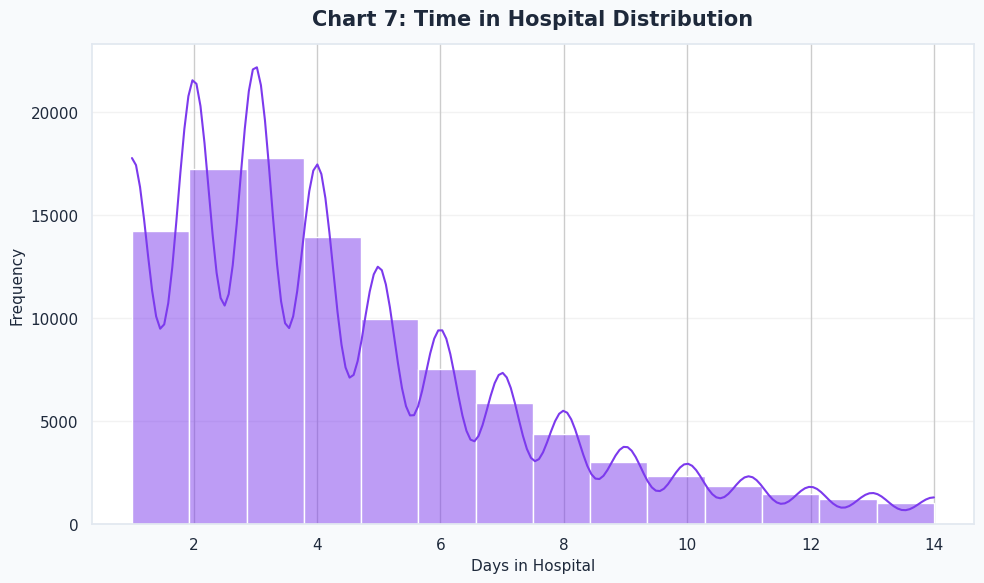

In [21]:
# CHART 7: Time in hospital distribution
plt.figure(figsize=(10, 6))
sns.histplot(clean_df['time_in_hospital'], bins=14, kde=True, color=THEME['secondary'])
finish_plot('Chart 7: Time in Hospital Distribution', 'Days in Hospital', 'Frequency')


## CHART 8: Number of medications distribution

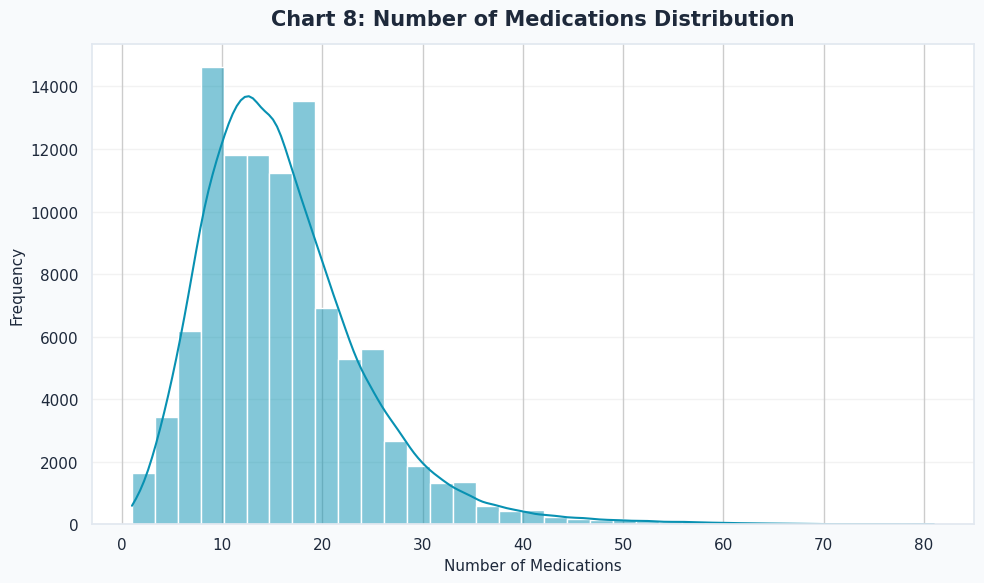

In [22]:
# CHART 8: Number of medications distribution
plt.figure(figsize=(10, 6))
sns.histplot(clean_df['num_medications'], bins=35, kde=True, color=THEME['accent'])
finish_plot('Chart 8: Number of Medications Distribution', 'Number of Medications', 'Frequency')


## CHART 9: Number of lab procedures distribution

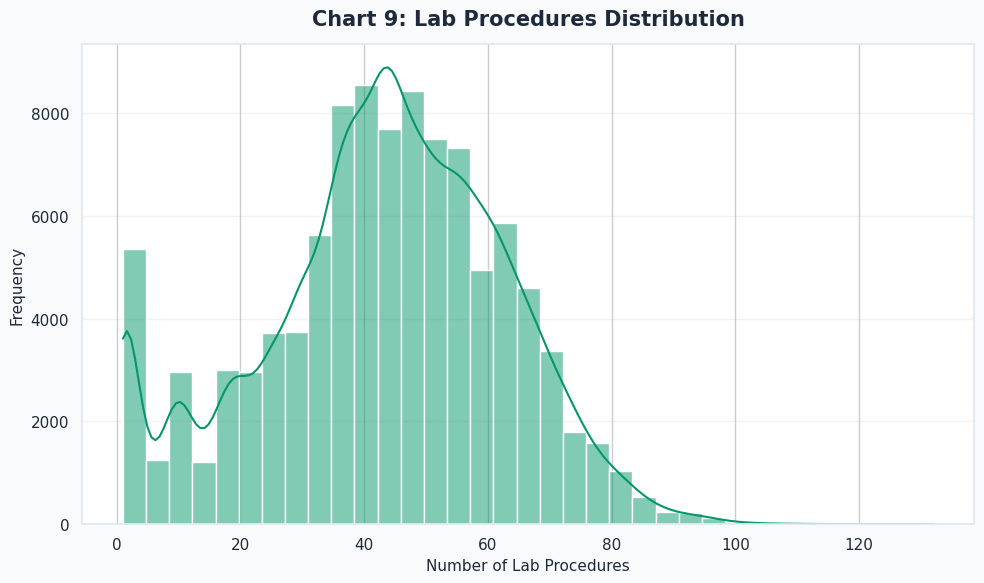

In [23]:
# CHART 9: Number of lab procedures distribution
plt.figure(figsize=(10, 6))
sns.histplot(clean_df['num_lab_procedures'], bins=35, kde=True, color=THEME['success'])
finish_plot('Chart 9: Lab Procedures Distribution', 'Number of Lab Procedures', 'Frequency')


## CHART 10: Number of procedures distribution

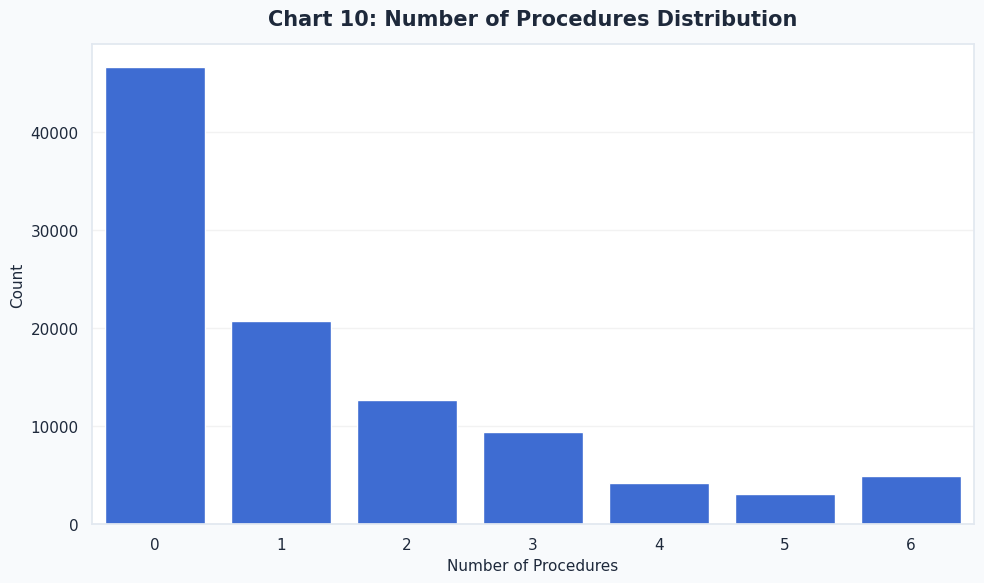

In [24]:
# CHART 10: Number of procedures distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=clean_df, x='num_procedures')
finish_plot('Chart 10: Number of Procedures Distribution', 'Number of Procedures', 'Count')


## CHART 11: Number of diagnoses distribution

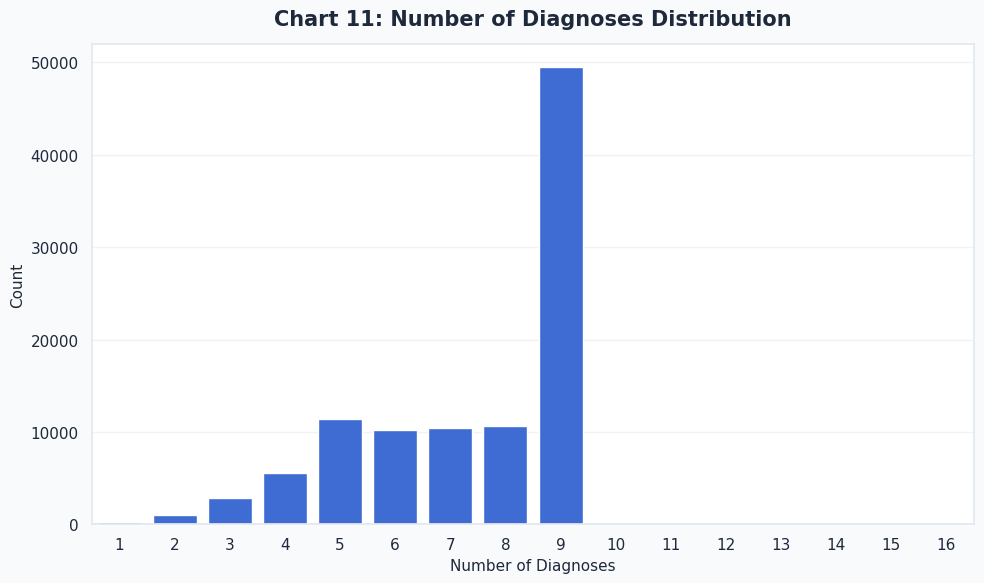

In [25]:
# CHART 11: Number of diagnoses distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=clean_df, x='number_diagnoses')
finish_plot('Chart 11: Number of Diagnoses Distribution', 'Number of Diagnoses', 'Count')


## CHART 12: Admission type ID distribution

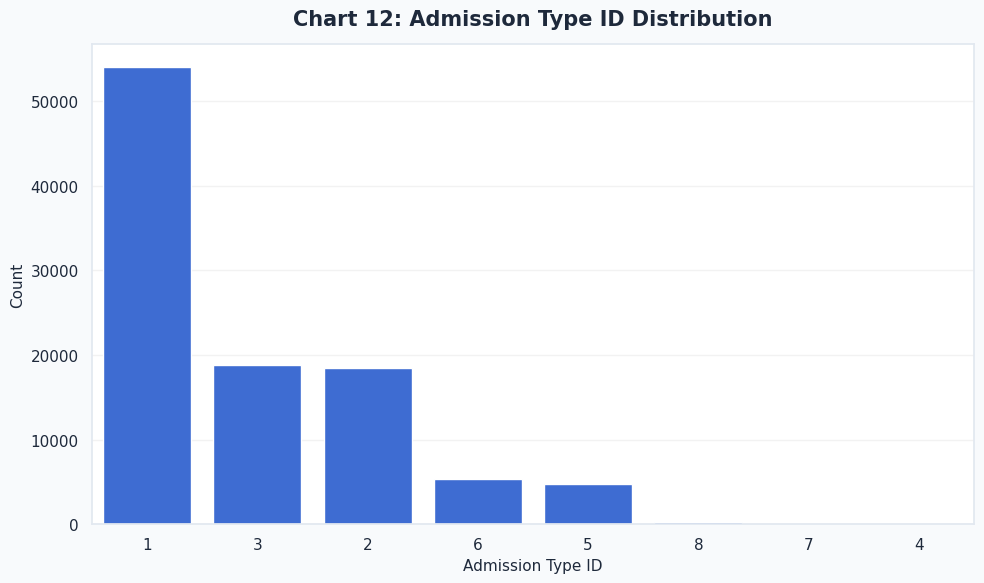

In [26]:
# CHART 12: Admission type ID distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=clean_df, x='admission_type_id', order=clean_df['admission_type_id'].value_counts().index)
finish_plot('Chart 12: Admission Type ID Distribution', 'Admission Type ID', 'Count')


## CHART 13: Discharge disposition ID distribution

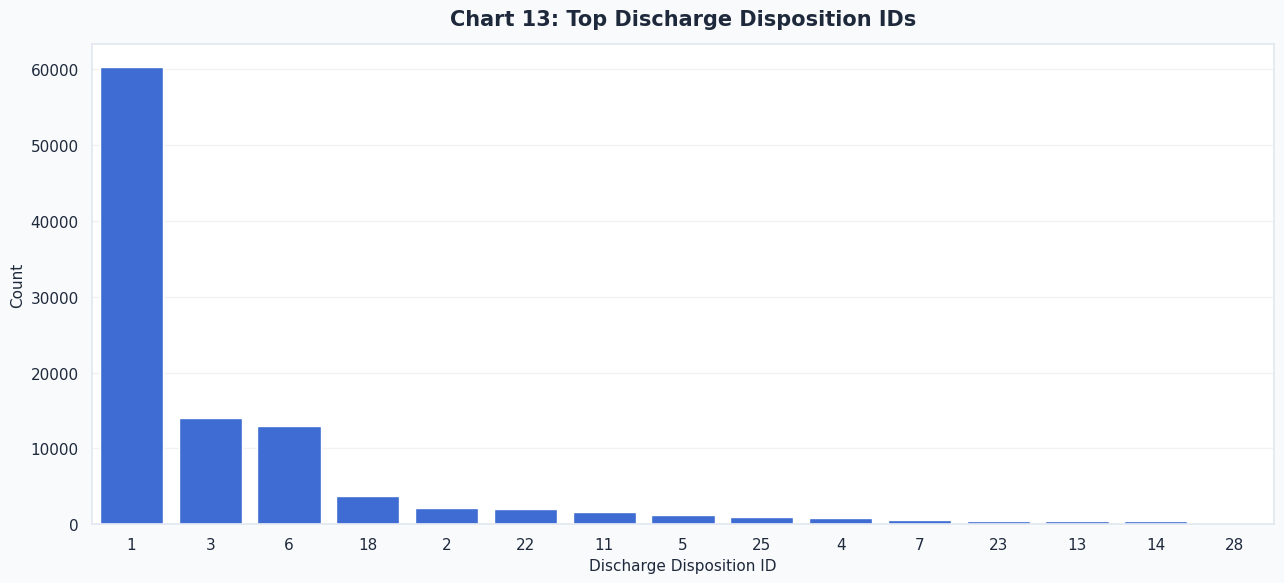

In [27]:
# CHART 13: Discharge disposition ID distribution
plt.figure(figsize=(13, 6))
top_discharge = clean_df['discharge_disposition_id'].value_counts().head(15).index
sns.countplot(data=clean_df[clean_df['discharge_disposition_id'].isin(top_discharge)], x='discharge_disposition_id', order=top_discharge)
finish_plot('Chart 13: Top Discharge Disposition IDs', 'Discharge Disposition ID', 'Count')


## CHART 14: Admission source ID distribution

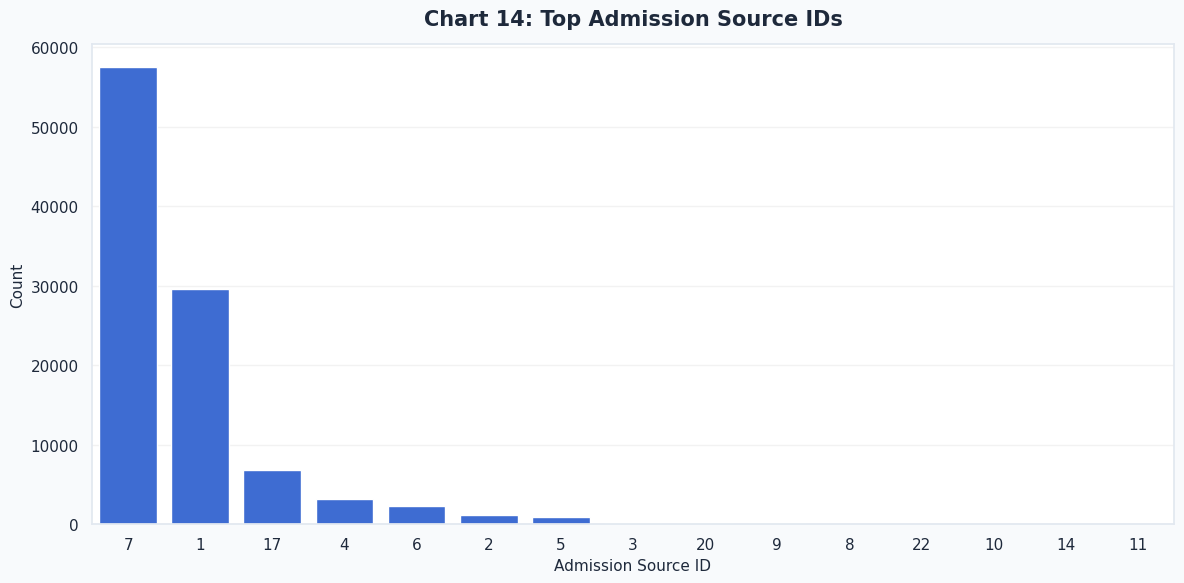

In [28]:
# CHART 14: Admission source ID distribution
plt.figure(figsize=(12, 6))
top_source = clean_df['admission_source_id'].value_counts().head(15).index
sns.countplot(data=clean_df[clean_df['admission_source_id'].isin(top_source)], x='admission_source_id', order=top_source)
finish_plot('Chart 14: Top Admission Source IDs', 'Admission Source ID', 'Count')


## CHART 15: Top medical specialties

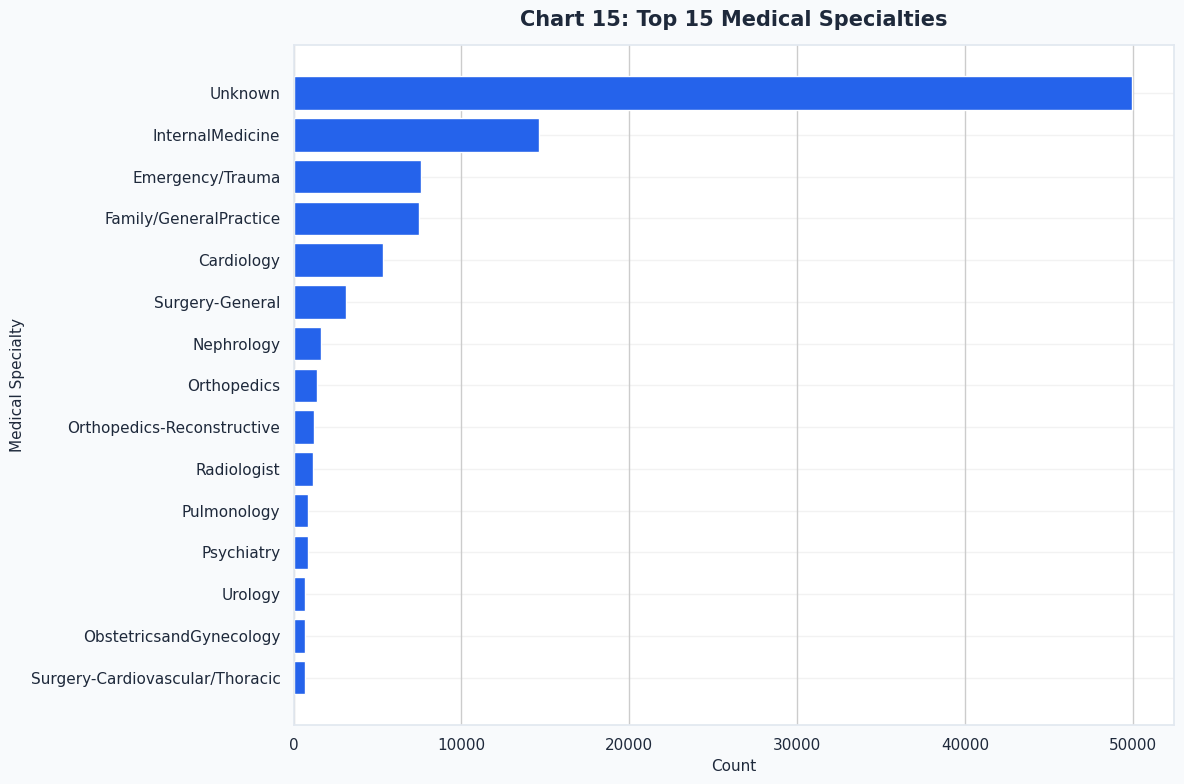

In [29]:
# CHART 15: Top medical specialties
plt.figure(figsize=(12, 8))
medical_specialty_series = clean_df['medical_specialty'].fillna('Unknown').value_counts().head(15).sort_values()
plt.barh(medical_specialty_series.index, medical_specialty_series.values, color=THEME['primary'])
finish_plot('Chart 15: Top 15 Medical Specialties', 'Count', 'Medical Specialty')


## CHART 16: A1C result distribution

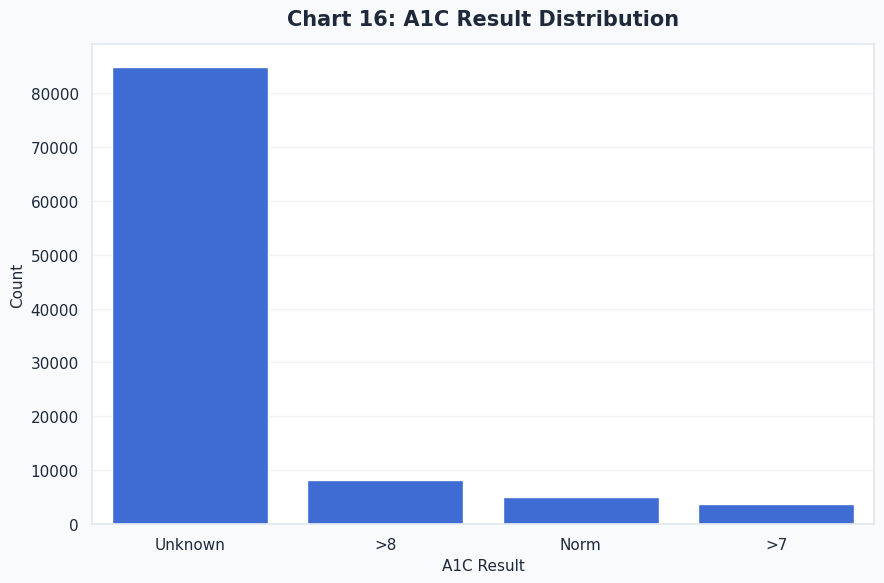

In [30]:
# CHART 16: A1C result distribution
plt.figure(figsize=(9, 6))
sns.countplot(data=clean_df.fillna({'A1Cresult':'Unknown'}), x='A1Cresult', order=clean_df['A1Cresult'].fillna('Unknown').value_counts().index)
finish_plot('Chart 16: A1C Result Distribution', 'A1C Result', 'Count')


## CHART 17: Max glucose serum distribution

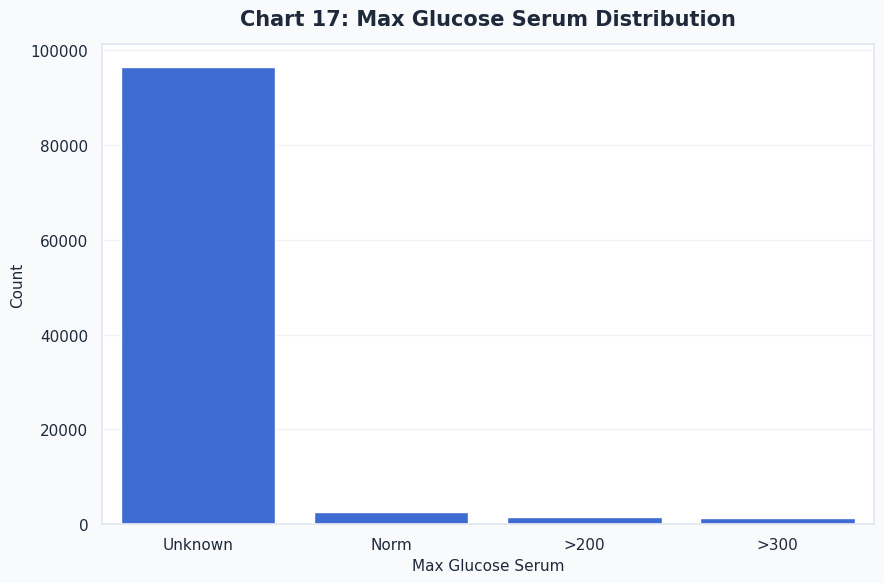

In [31]:
# CHART 17: Max glucose serum distribution
plt.figure(figsize=(9, 6))
sns.countplot(data=clean_df.fillna({'max_glu_serum':'Unknown'}), x='max_glu_serum', order=clean_df['max_glu_serum'].fillna('Unknown').value_counts().index)
finish_plot('Chart 17: Max Glucose Serum Distribution', 'Max Glucose Serum', 'Count')


## CHART 18: Insulin status

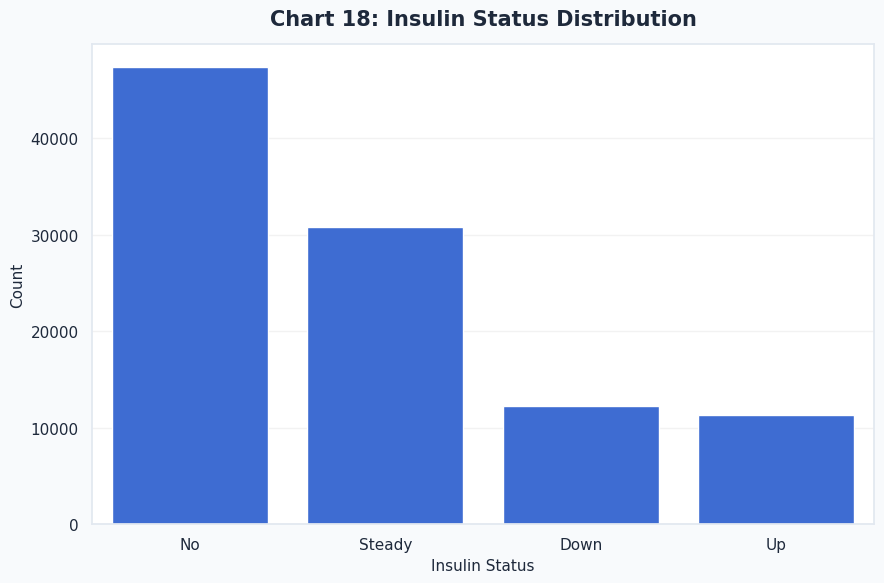

In [32]:
# CHART 18: Insulin status
plt.figure(figsize=(9, 6))
sns.countplot(data=clean_df, x='insulin', order=clean_df['insulin'].value_counts().index)
finish_plot('Chart 18: Insulin Status Distribution', 'Insulin Status', 'Count')


## CHART 19: Medication change status

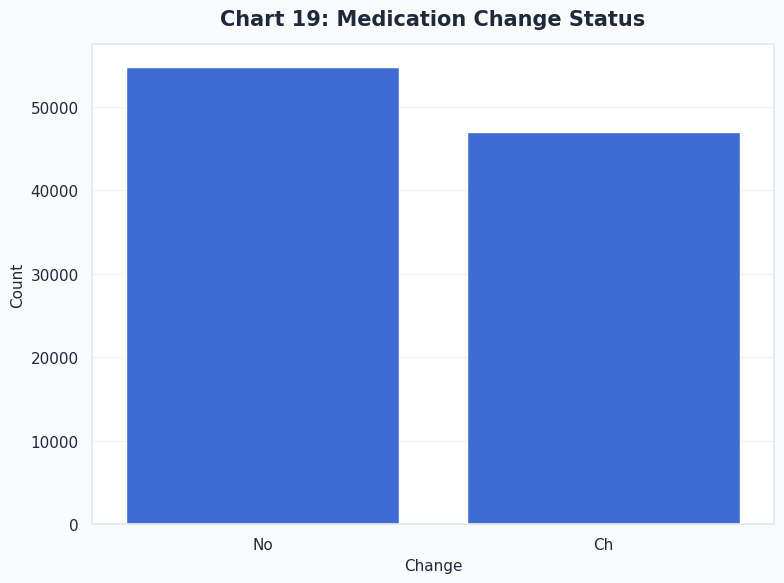

In [33]:
# CHART 19: Medication change status
plt.figure(figsize=(8, 6))
sns.countplot(data=clean_df, x='change', order=clean_df['change'].value_counts().index)
finish_plot('Chart 19: Medication Change Status', 'Change', 'Count')


## CHART 20: Diabetes medication status

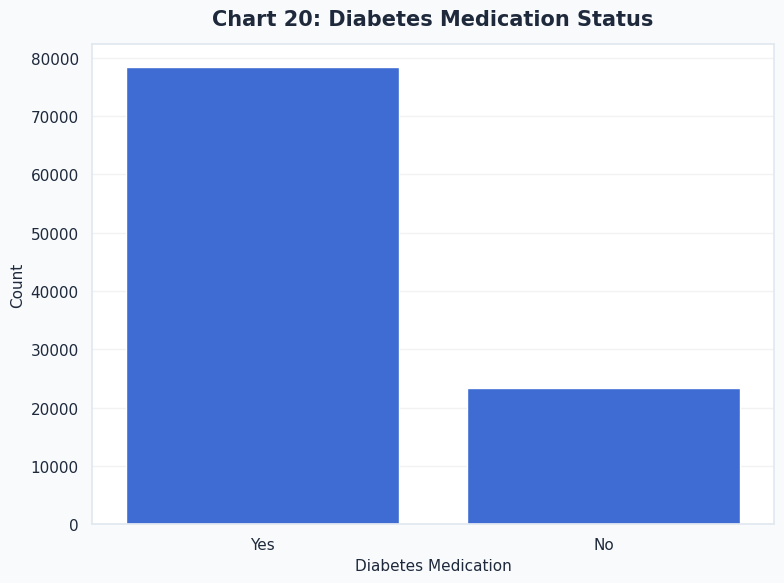

In [34]:
# CHART 20: Diabetes medication status
plt.figure(figsize=(8, 6))
sns.countplot(data=clean_df, x='diabetesMed', order=clean_df['diabetesMed'].value_counts().index)
finish_plot('Chart 20: Diabetes Medication Status', 'Diabetes Medication', 'Count')


## CHART 21: Medication change count

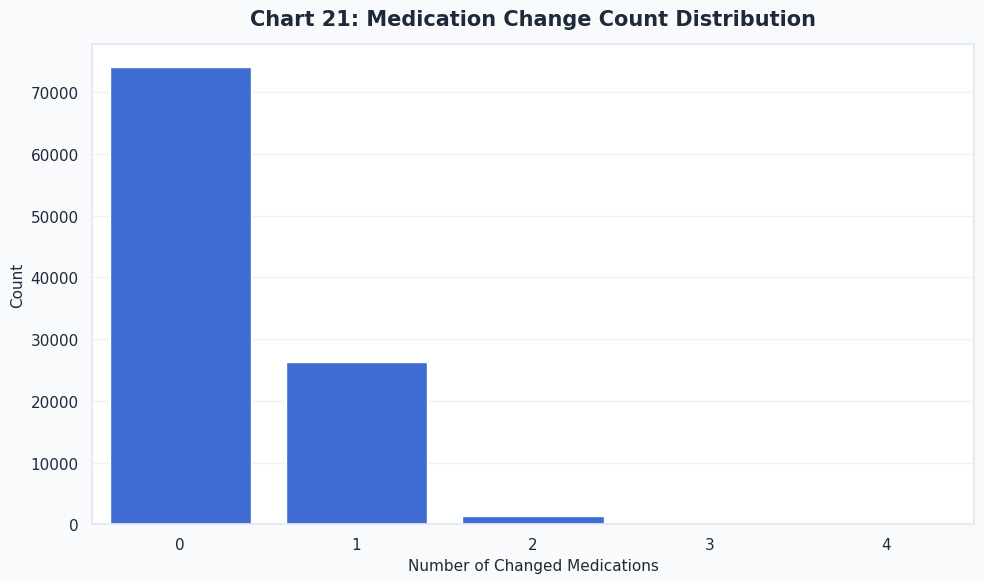

In [35]:
# CHART 21: Medication change count
plt.figure(figsize=(10, 6))
sns.countplot(data=clean_df, x='medication_change_count')
finish_plot('Chart 21: Medication Change Count Distribution', 'Number of Changed Medications', 'Count')


## CHART 22: Missing values before cleaning

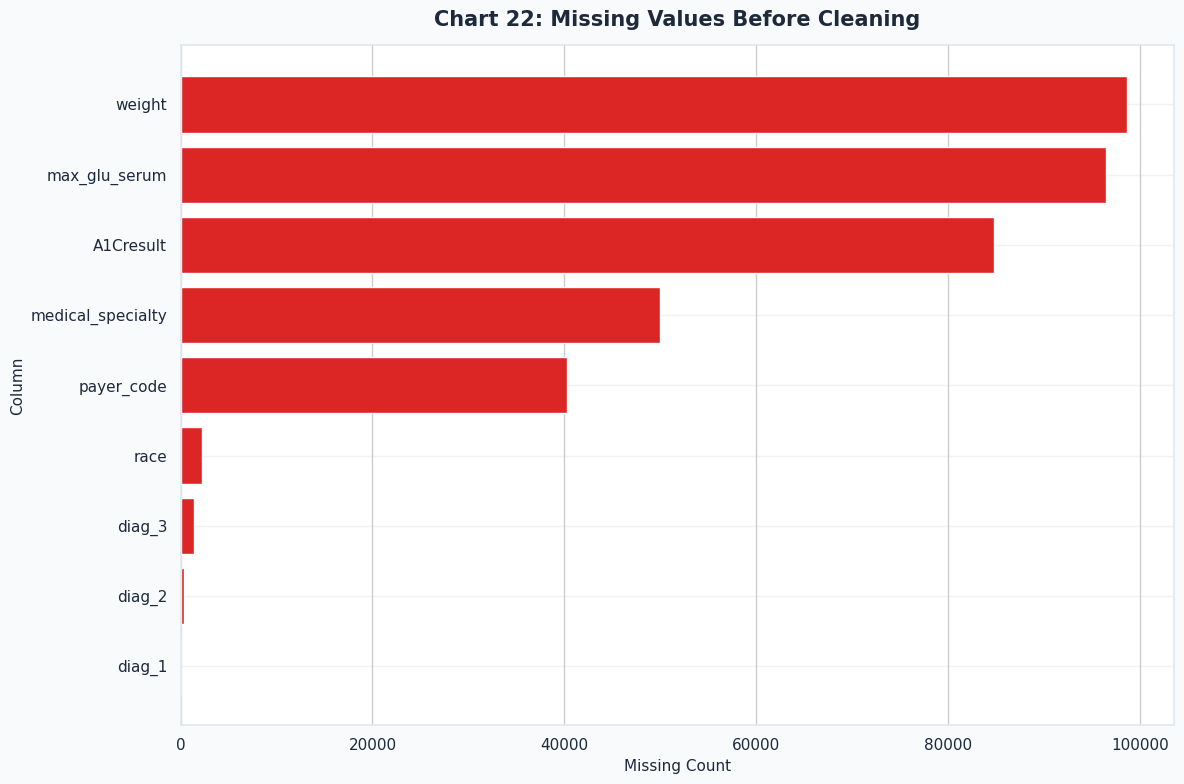

In [36]:
# CHART 22: Missing values before cleaning
plt.figure(figsize=(12, 8))
top_missing_before = missing_before[missing_before['Missing_Count'] > 0].head(15).sort_values('Missing_Count')
plt.barh(top_missing_before.index, top_missing_before['Missing_Count'], color=THEME['danger'])
finish_plot('Chart 22: Missing Values Before Cleaning', 'Missing Count', 'Column')


## CHART 23: Missing values after cleaning

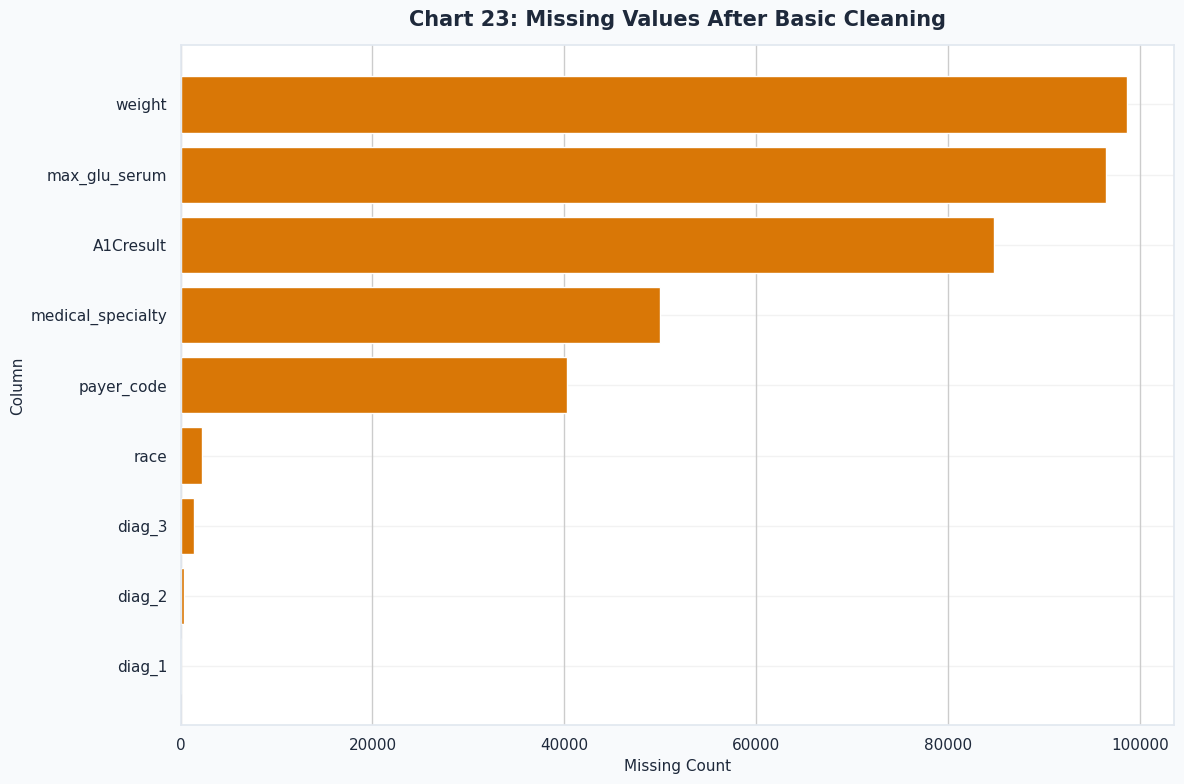

In [37]:
# CHART 23: Missing values after cleaning
plt.figure(figsize=(12, 8))
top_missing_after = missing_after[missing_after['Missing_Count'] > 0].head(15).sort_values('Missing_Count')
if len(top_missing_after) > 0:
    plt.barh(top_missing_after.index, top_missing_after['Missing_Count'], color=THEME['warning'])
else:
    plt.barh(['No missing values'], [0], color=THEME['success'])
finish_plot('Chart 23: Missing Values After Basic Cleaning', 'Missing Count', 'Column')


## CHART 24: Numeric correlation heatmap

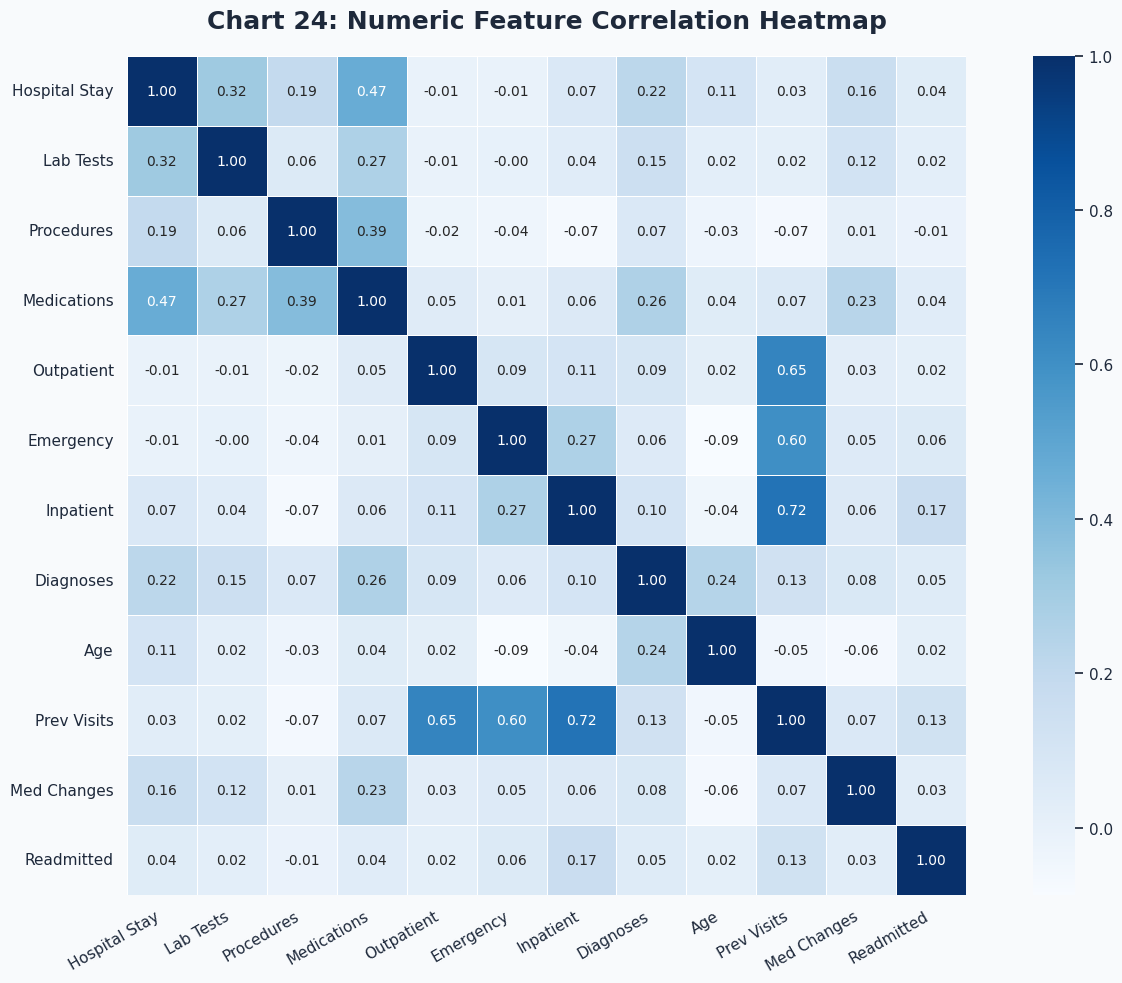

In [69]:
# CHART 24: Numeric Feature Correlation Heatmap

numeric_cols_for_corr = clean_df.select_dtypes(include=np.number).columns.tolist()

selected_corr_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses',
    'age_midpoint',
    'total_previous_visits',
    'medication_change_count',
    'readmitted_30_days'
]

selected_corr_cols = [col for col in selected_corr_cols if col in numeric_cols_for_corr]

# Create shorter labels for presentation-quality chart
short_names = {
    'time_in_hospital': 'Hospital Stay',
    'num_lab_procedures': 'Lab Tests',
    'num_procedures': 'Procedures',
    'num_medications': 'Medications',
    'number_outpatient': 'Outpatient',
    'number_emergency': 'Emergency',
    'number_inpatient': 'Inpatient',
    'number_diagnoses': 'Diagnoses',
    'age_midpoint': 'Age',
    'total_previous_visits': 'Prev Visits',
    'medication_change_count': 'Med Changes',
    'readmitted_30_days': 'Readmitted'
}

corr_matrix = clean_df[selected_corr_cols].corr()

corr_matrix.rename(
    index=short_names,
    columns=short_names,
    inplace=True
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.7,
    square=True,
    annot_kws={"size": 10}
)

plt.title(
    "Chart 24: Numeric Feature Correlation Heatmap",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xticks(
    rotation=30,
    ha='right',
    fontsize=11
)

plt.yticks(
    rotation=0,
    fontsize=11
)

plt.tight_layout()

plt.savefig(
    "chart24_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## CHART 25: Readmission rate by age group

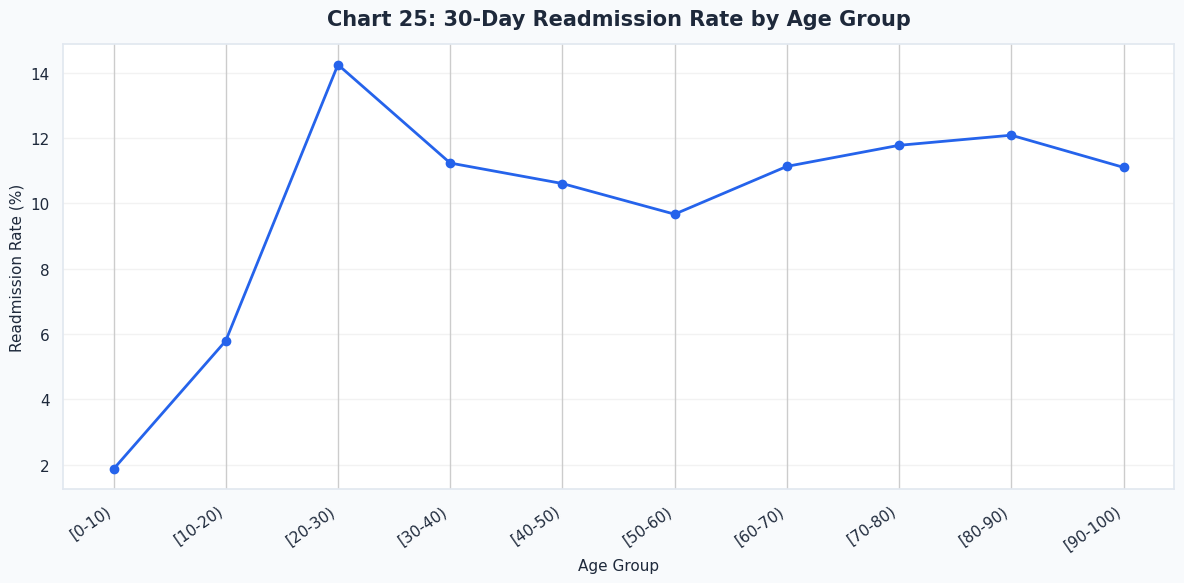

In [39]:
# CHART 25: Readmission rate by age group
plt.figure(figsize=(12, 6))
age_rate = clean_df.groupby('age')['readmitted_30_days'].mean().reindex(age_order) * 100
plt.plot(age_rate.index, age_rate.values, marker='o', linewidth=2, color=THEME['primary'])
finish_plot('Chart 25: 30-Day Readmission Rate by Age Group', 'Age Group', 'Readmission Rate (%)', 35)


## CHART 26: Readmission rate by gender

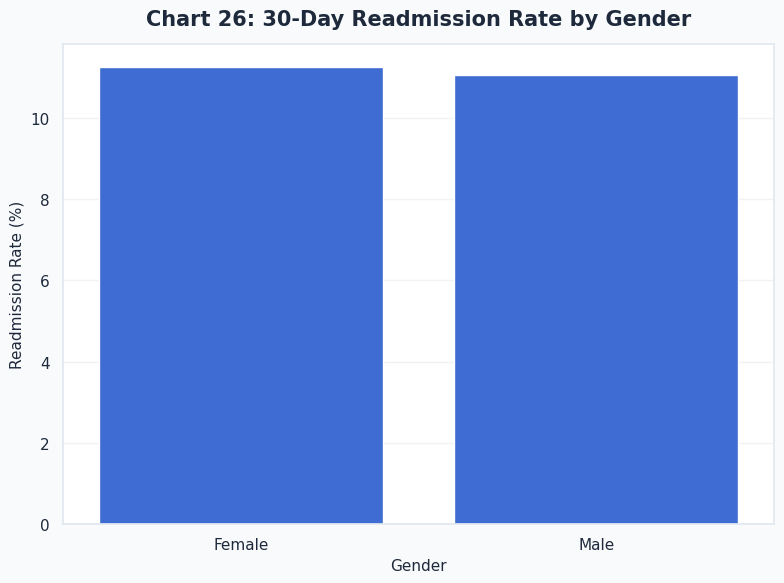

In [40]:
# CHART 26: Readmission rate by gender
plt.figure(figsize=(8, 6))
gender_rate = clean_df.groupby('gender')['readmitted_30_days'].mean().sort_values(ascending=False) * 100
sns.barplot(x=gender_rate.index, y=gender_rate.values)
finish_plot('Chart 26: 30-Day Readmission Rate by Gender', 'Gender', 'Readmission Rate (%)')


## CHART 27: Readmission rate by race

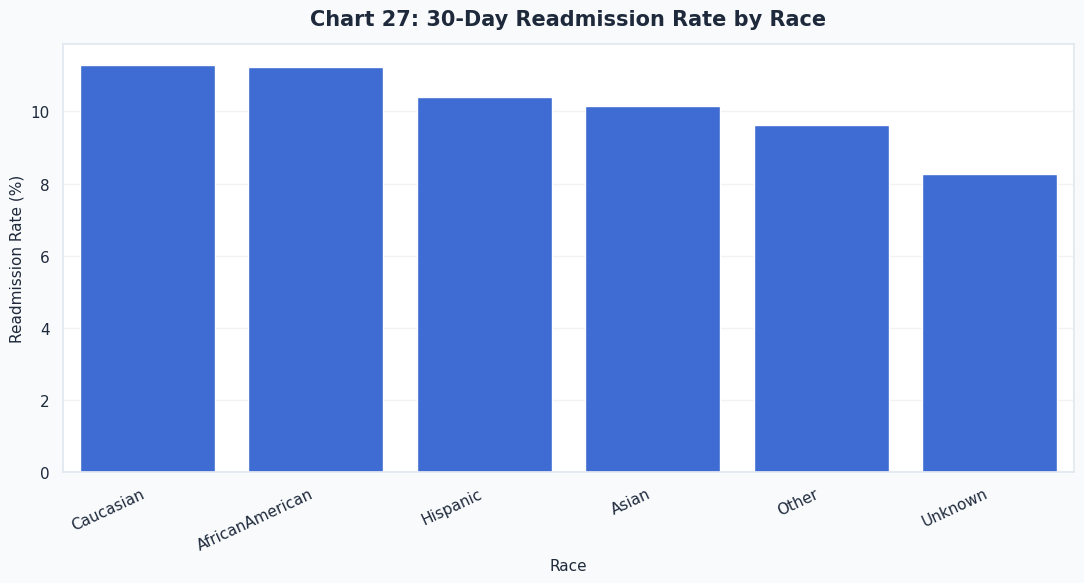

In [41]:
# CHART 27: Readmission rate by race
plt.figure(figsize=(11, 6))
race_rate = clean_df.groupby(clean_df['race'].fillna('Unknown'))['readmitted_30_days'].mean().sort_values(ascending=False) * 100
sns.barplot(x=race_rate.index, y=race_rate.values)
finish_plot('Chart 27: 30-Day Readmission Rate by Race', 'Race', 'Readmission Rate (%)', 25)


## CHART 28: Time in hospital by readmission class

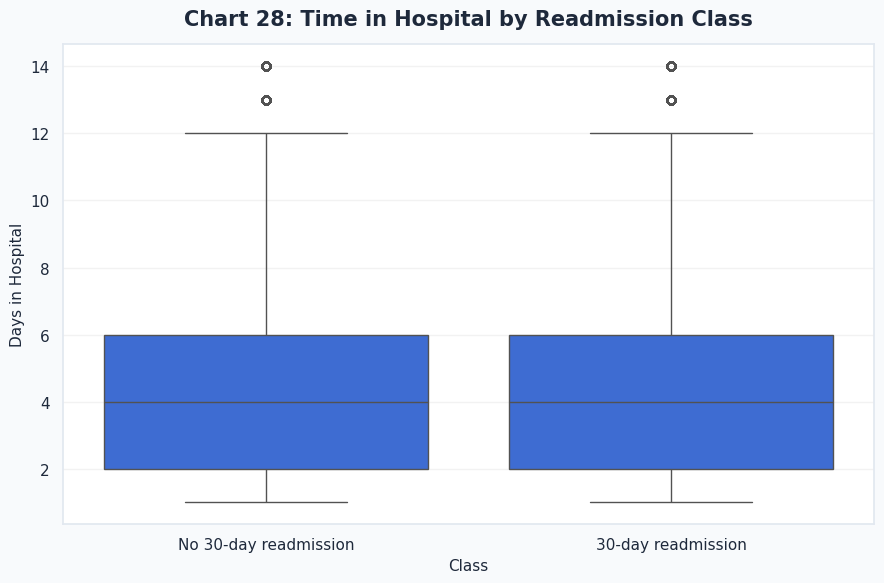

In [42]:
# CHART 28: Time in hospital by readmission class
plt.figure(figsize=(9, 6))
sns.boxplot(data=clean_df, x='readmitted_30_days', y='time_in_hospital')
plt.xticks([0,1], ['No 30-day readmission', '30-day readmission'])
finish_plot('Chart 28: Time in Hospital by Readmission Class', 'Class', 'Days in Hospital')


## CHART 29: Number of medications by readmission class

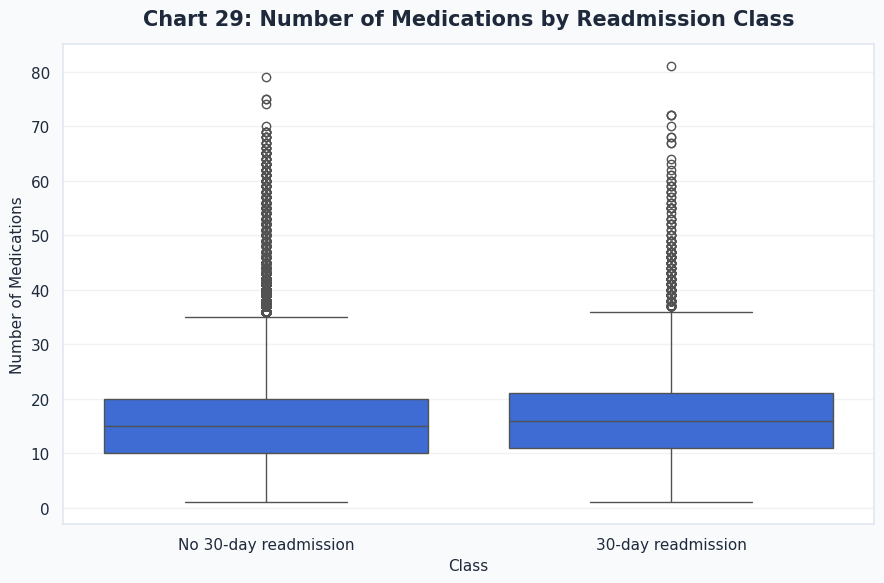

In [43]:
# CHART 29: Number of medications by readmission class
plt.figure(figsize=(9, 6))
sns.boxplot(data=clean_df, x='readmitted_30_days', y='num_medications')
plt.xticks([0,1], ['No 30-day readmission', '30-day readmission'])
finish_plot('Chart 29: Number of Medications by Readmission Class', 'Class', 'Number of Medications')


## CHART 30: Previous visits by readmission class

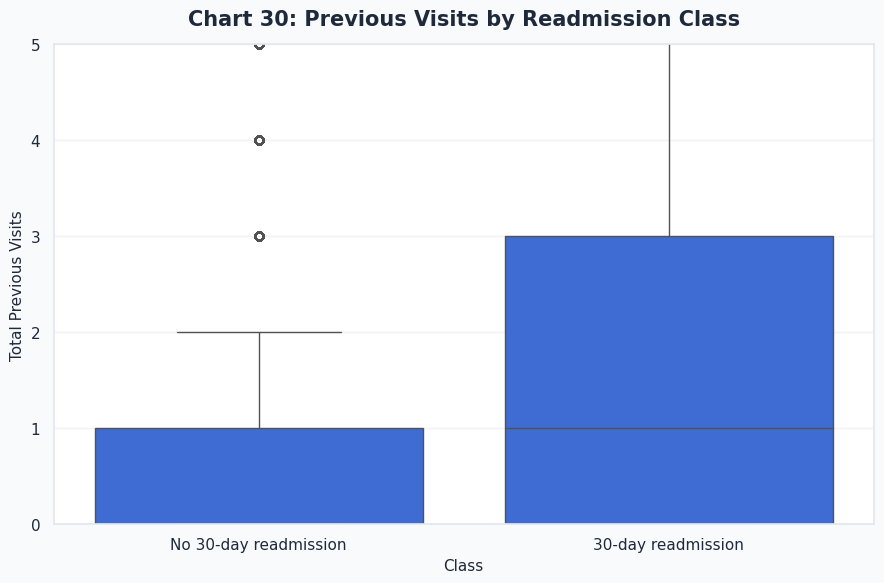

In [44]:
# CHART 30: Previous visits by readmission class
plt.figure(figsize=(9, 6))
sns.boxplot(data=clean_df, x='readmitted_30_days', y='total_previous_visits')
plt.ylim(0, clean_df['total_previous_visits'].quantile(0.95))
plt.xticks([0,1], ['No 30-day readmission', '30-day readmission'])
finish_plot('Chart 30: Previous Visits by Readmission Class', 'Class', 'Total Previous Visits')


## CHART 31: Primary diagnosis group count

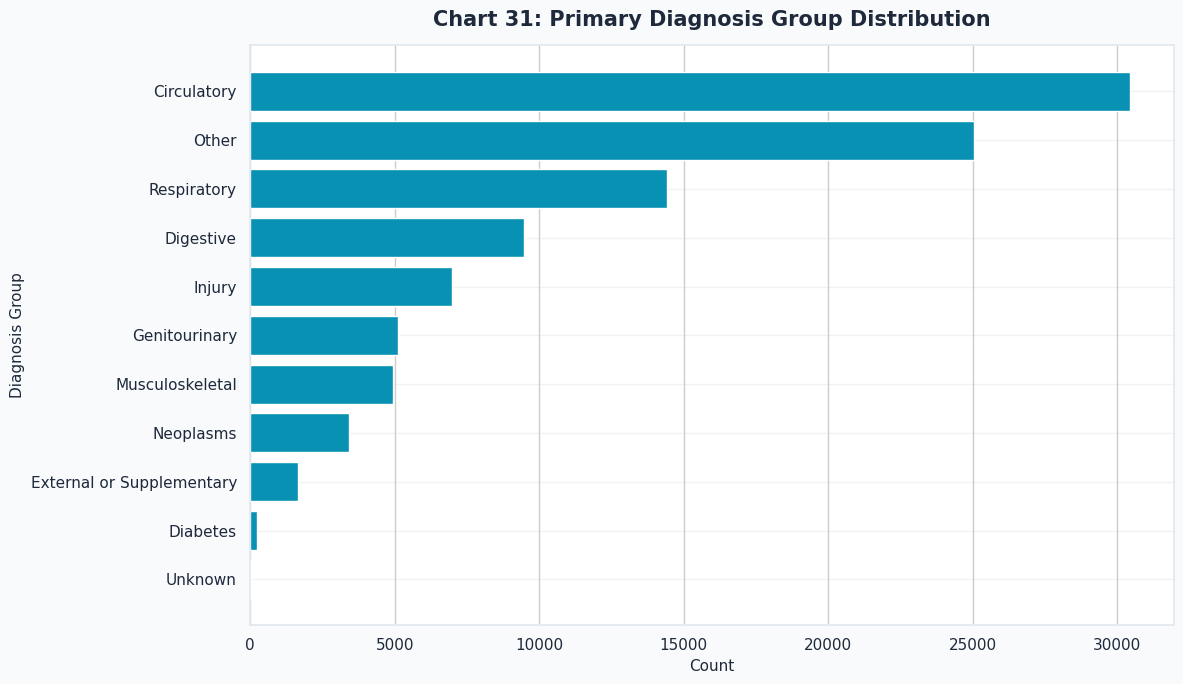

In [45]:
# CHART 31: Primary diagnosis group count
plt.figure(figsize=(12, 7))
diag_counts = clean_df['primary_diagnosis_group'].value_counts().sort_values()
plt.barh(diag_counts.index, diag_counts.values, color=THEME['accent'])
finish_plot('Chart 31: Primary Diagnosis Group Distribution', 'Count', 'Diagnosis Group')


## CHART 32: Readmission rate by diagnosis group

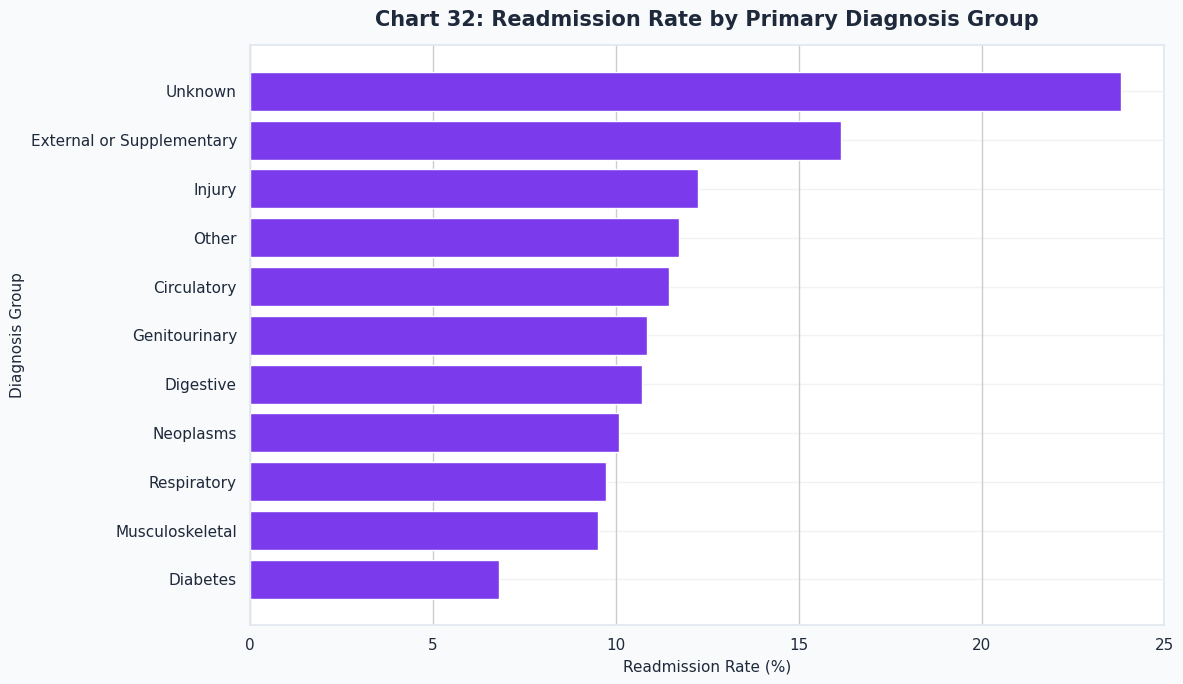

In [46]:
# CHART 32: Readmission rate by diagnosis group
plt.figure(figsize=(12, 7))
diag_rate = clean_df.groupby('primary_diagnosis_group')['readmitted_30_days'].mean().sort_values() * 100
plt.barh(diag_rate.index, diag_rate.values, color=THEME['secondary'])
finish_plot('Chart 32: Readmission Rate by Primary Diagnosis Group', 'Readmission Rate (%)', 'Diagnosis Group')


## CHART 33: Readmission class proportion pie chart

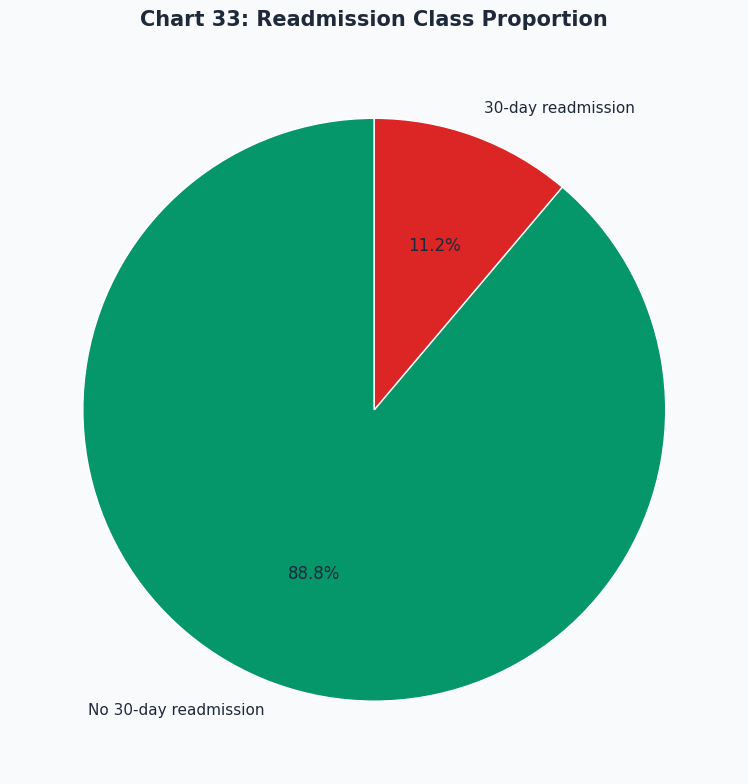

In [47]:
# CHART 33: Readmission class proportion pie chart
plt.figure(figsize=(8, 8))
class_counts = clean_df['readmitted_30_days'].value_counts().sort_index()
plt.pie(class_counts.values, labels=['No 30-day readmission', '30-day readmission'], autopct='%1.1f%%', startangle=90, colors=[THEME['success'], THEME['danger']])
plt.title('Chart 33: Readmission Class Proportion', fontsize=15, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()


# Data Science Questions and Answers

The following questions are answered using the dataset. Each answer is generated from code, so the output updates automatically when the notebook is executed.

# Data Science Questions and Answers

Each question is answered in a separate cell so the output is clear.

## Question 1: What percentage of patients were readmitted within 30 days?

In [48]:
print('Question 1: What percentage of patients were readmitted within 30 days?')
answer1 = clean_df['readmitted_30_days'].mean() * 100
print(f'Answer: {answer1:.2f}% of hospital encounters resulted in readmission within 30 days.')


Question 1: What percentage of patients were readmitted within 30 days?
Answer: 11.16% of hospital encounters resulted in readmission within 30 days.


## Question 2: Which age group has the highest 30-day readmission rate?

In [49]:
print('Question 2: Which age group has the highest 30-day readmission rate?')
answer2 = (clean_df.groupby('age')['readmitted_30_days'].mean() * 100).sort_values(ascending=False)
display(answer2.head(5).to_frame('Readmission_Rate_Percentage'))


Question 2: Which age group has the highest 30-day readmission rate?


,Readmission_Rate_Percentage
age,
[20-30),14.242607
[80-90),12.083503
[70-80),11.773958
[30-40),11.231788
[60-70),11.128903


## Question 3: Do patients with more previous visits have higher readmission risk?

In [50]:
print('Question 3: Do patients with more previous visits have higher readmission risk?')
visit_summary = clean_df.groupby('readmitted_30_days')['total_previous_visits'].mean()
display(visit_summary.to_frame('Average_Total_Previous_Visits'))
print('Answer: Compare the averages above. A higher value for class 1 shows greater previous-visit history among readmitted patients.')


Question 3: Do patients with more previous visits have higher readmission risk?


,Average_Total_Previous_Visits
readmitted_30_days,
0,1.100358
1,2.018227


Answer: Compare the averages above. A higher value for class 1 shows greater previous-visit history among readmitted patients.


## Question 4: Which primary diagnosis group has the highest readmission rate?

In [51]:
print('Question 4: Which primary diagnosis group has the highest readmission rate?')
diag_answer = (
    clean_df.groupby('primary_diagnosis_group')['readmitted_30_days']
    .agg(['count', 'mean'])
    .assign(Readmission_Rate_Percentage=lambda x: x['mean'] * 100)
    .sort_values('Readmission_Rate_Percentage', ascending=False)
)
display(diag_answer.head(10))


Question 4: Which primary diagnosis group has the highest readmission rate?


,count,mean,Readmission_Rate_Percentage
primary_diagnosis_group,,,
Unknown,21,0.238095,23.809524
External or Supplementary,1645,0.161702,16.170213
Injury,6972,0.122490,12.248996
Other,25049,0.117410,11.740988
Circulatory,30436,0.114503,11.450256
Genitourinary,5117,0.108462,10.846199
Digestive,9475,0.107124,10.712401
Neoplasms,3433,0.100786,10.078648
Respiratory,14423,0.097275,9.727519


## Question 5: Is readmission rate different by gender?

In [52]:
print('Question 5: Is readmission rate different by gender?')
gender_answer = (clean_df.groupby('gender')['readmitted_30_days'].mean() * 100).sort_values(ascending=False)
display(gender_answer.to_frame('Readmission_Rate_Percentage'))


Question 5: Is readmission rate different by gender?


,Readmission_Rate_Percentage
gender,
Female,11.245156
Male,11.061524


## Question 6: What is the average hospital stay for readmitted and non-readmitted patients?

In [53]:
print('Question 6: What is the average hospital stay for readmitted and non-readmitted patients?')
stay_answer = clean_df.groupby('readmitted_30_days')['time_in_hospital'].mean()
display(stay_answer.to_frame('Average_Time_In_Hospital'))


Question 6: What is the average hospital stay for readmitted and non-readmitted patients?


,Average_Time_In_Hospital
readmitted_30_days,
0,4.349258
1,4.768249


## Question 7: Which race group has the highest 30-day readmission rate?

In [54]:
print('Question 7: Which race group has the highest 30-day readmission rate?')
race_answer = (clean_df.groupby(clean_df['race'].fillna('Unknown'))['readmitted_30_days'].mean() * 100).sort_values(ascending=False)
display(race_answer.to_frame('Readmission_Rate_Percentage'))


Question 7: Which race group has the highest 30-day readmission rate?


,Readmission_Rate_Percentage
race,
Caucasian,11.290556
AfricanAmerican,11.218116
Hispanic,10.407462
Asian,10.140406
Other,9.634551
Unknown,8.278292


## Question 8: Does insulin status relate to readmission?

In [55]:
print('Question 8: Does insulin status relate to readmission?')
insulin_answer = (clean_df.groupby('insulin')['readmitted_30_days'].mean() * 100).sort_values(ascending=False)
display(insulin_answer.to_frame('Readmission_Rate_Percentage'))


Question 8: Does insulin status relate to readmission?


,Readmission_Rate_Percentage
insulin,
Down,13.897528
Up,12.990456
Steady,11.128400
No,10.037991


## Question 9: What is the relationship between number of medications and readmission?

In [56]:
print('Question 9: What is the relationship between number of medications and readmission?')
med_answer = clean_df.groupby('readmitted_30_days')['num_medications'].mean()
display(med_answer.to_frame('Average_Number_Of_Medications'))


Question 9: What is the relationship between number of medications and readmission?


,Average_Number_Of_Medications
readmitted_30_days,
0,15.911123
1,16.903143


## Question 10: What are the strongest numeric correlations with 30-day readmission?

In [57]:
print('Question 10: What are the strongest numeric correlations with 30-day readmission?')
if 'selected_corr_cols' not in globals():
    selected_corr_cols = [
        'time_in_hospital', 'num_lab_procedures', 'num_procedures',
        'num_medications', 'number_outpatient', 'number_emergency',
        'number_inpatient', 'number_diagnoses', 'age_midpoint',
        'total_previous_visits', 'medication_change_count', 'readmitted_30_days'
    ]
    selected_corr_cols = [c for c in selected_corr_cols if c in clean_df.columns]

corr_answer = clean_df[selected_corr_cols].corr()['readmitted_30_days'].sort_values(ascending=False)
display(corr_answer.to_frame('Correlation_With_Readmission_30_Days'))


Question 10: What are the strongest numeric correlations with 30-day readmission?


,Correlation_With_Readmission_30_Days
readmitted_30_days,1.000000
number_inpatient,0.165143
total_previous_visits,0.126109
number_emergency,0.060744
number_diagnoses,0.049518
time_in_hospital,0.044197
num_medications,0.038433
medication_change_count,0.034913
num_lab_procedures,0.020359
number_outpatient,0.018890


# Machine Learning Model Building

The machine learning goal is to predict whether a patient will be readmitted within 30 days.

Target variable:

- `readmitted_30_days = 1`: patient was readmitted within 30 days  
- `readmitted_30_days = 0`: patient was not readmitted within 30 days

The notebook uses a preprocessing pipeline with imputation, scaling, one-hot encoding, and multiple classification models.

# Prepare Data for Machine Learning

The feature selection and train-test split are separated for clarity.

In [58]:
# 10.1 Select input features and target variable
columns_to_drop = [
    'readmitted', 'readmitted_30_days',
    'encounter_id', 'patient_nbr'
]

model_df = clean_df.drop(columns=[c for c in columns_to_drop if c in clean_df.columns], errors='ignore')
target = clean_df['readmitted_30_days']

print('Initial model input shape:', model_df.shape)
print('Target shape:', target.shape)


Initial model input shape: (101763, 51)
Target shape: (101763,)


In [59]:
# 10.2 Remove very high-cardinality columns that can slow down encoding
high_noise_cols = ['diag_1', 'diag_2', 'diag_3', 'payer_code']
model_df = model_df.drop(columns=[c for c in high_noise_cols if c in model_df.columns], errors='ignore')

print('Model input shape after removing high-cardinality columns:', model_df.shape)


Model input shape after removing high-cardinality columns: (101763, 47)


In [60]:
# 10.3 Identify numeric and categorical features
numeric_features = model_df.select_dtypes(include=np.number).columns.tolist()
categorical_features = model_df.select_dtypes(exclude=np.number).columns.tolist()

print('Numeric features:', len(numeric_features))
print('Categorical features:', len(categorical_features))


Numeric features: 14
Categorical features: 33


In [61]:
# 10.4 Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    model_df,
    target,
    test_size=0.20,
    random_state=42,
    stratify=target
)

print('Training shape:', X_train.shape)
print('Testing shape:', X_test.shape)
print('Training target distribution:')
print(y_train.value_counts(normalize=True).round(4))


Training shape: (81410, 47)
Testing shape: (20353, 47)
Training target distribution:
readmitted_30_days
0    0.8884
1    0.1116
Name: proportion, dtype: float64


In [62]:
# ============================================================
# 11. PREPROCESSING PIPELINE
# ============================================================

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Compatibility for different sklearn versions
try:
    categorical_encoder = OneHotEncoder(handle_unknown='ignore', min_frequency=50, sparse_output=True)
except TypeError:
    categorical_encoder = OneHotEncoder(handle_unknown='ignore')

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', categorical_encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print('Preprocessing pipeline created successfully.')

Preprocessing pipeline created successfully.


# Train Machine Learning Models

The models are defined first, then trained and evaluated in the next cell.

In [63]:
# 12.1 Define machine learning models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=12, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=80, max_depth=14, class_weight='balanced', random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesClassifier(n_estimators=80, max_depth=14, class_weight='balanced', random_state=42, n_jobs=-1)
}

print('Models defined:', list(models.keys()))


Models defined: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Extra Trees']


In [64]:
# 12.2 Train models and calculate evaluation metrics
results = []
trained_models = {}

for model_name, model in models.items():
    print(f'Training {model_name}...')
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1_Score': f1
    })
    trained_models[model_name] = clf

results_df = pd.DataFrame(results).sort_values(by='F1_Score', ascending=False)
print('Model comparison results:')
display(results_df)


Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Extra Trees...
Model comparison results:


,Model,Accuracy,Precision,Recall,F1_Score
2,Random Forest,0.760674,0.209432,0.412594,0.277835
0,Logistic Regression,0.659018,0.173451,0.546015,0.263270
3,Extra Trees,0.684862,0.175466,0.493175,0.258840
1,Decision Tree,0.644770,0.168206,0.553501,0.258005


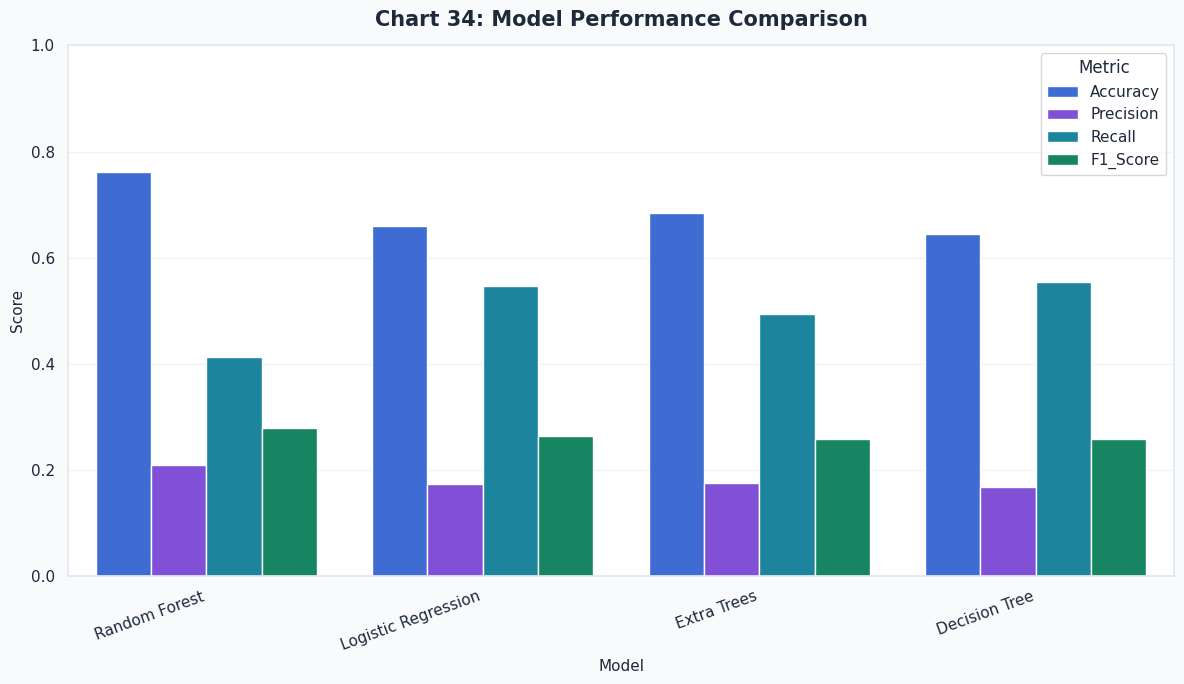

In [65]:
# ============================================================
# 13. CHART 34: MODEL PERFORMANCE COMPARISON
# ============================================================

plt.figure(figsize=(12, 7))
results_melted = results_df.melt(id_vars='Model', value_vars=['Accuracy', 'Precision', 'Recall', 'F1_Score'], var_name='Metric', value_name='Score')
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric')
plt.ylim(0, 1)
finish_plot('Chart 34: Model Performance Comparison', 'Model', 'Score', 20)

In [66]:
# ============================================================
# 14. BEST MODEL SELECTION AND DETAILED EVALUATION
# ============================================================

best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

print('Best model based on F1 Score:', best_model_name)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_best, target_names=['No 30-day readmission', '30-day readmission']))

best_accuracy = accuracy_score(y_test, y_pred_best)
print(f'Best Model Accuracy: {best_accuracy:.4f}')

Best model based on F1 Score: Random Forest

Classification Report:
                       precision    recall  f1-score   support

No 30-day readmission       0.92      0.80      0.86     18082
   30-day readmission       0.21      0.41      0.28      2271

             accuracy                           0.76     20353
            macro avg       0.56      0.61      0.57     20353
         weighted avg       0.84      0.76      0.79     20353

Best Model Accuracy: 0.7607


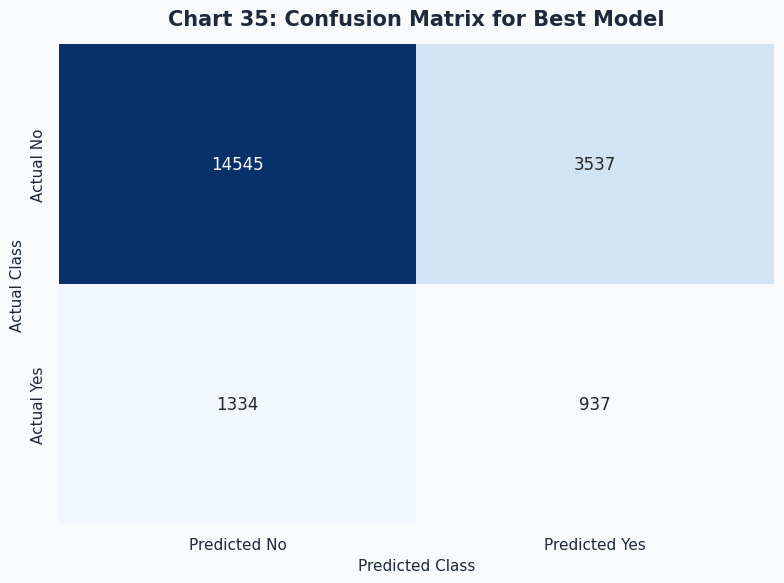

In [67]:
# ============================================================
# 15. CHART 35: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
finish_plot('Chart 35: Confusion Matrix for Best Model', 'Predicted Class', 'Actual Class')

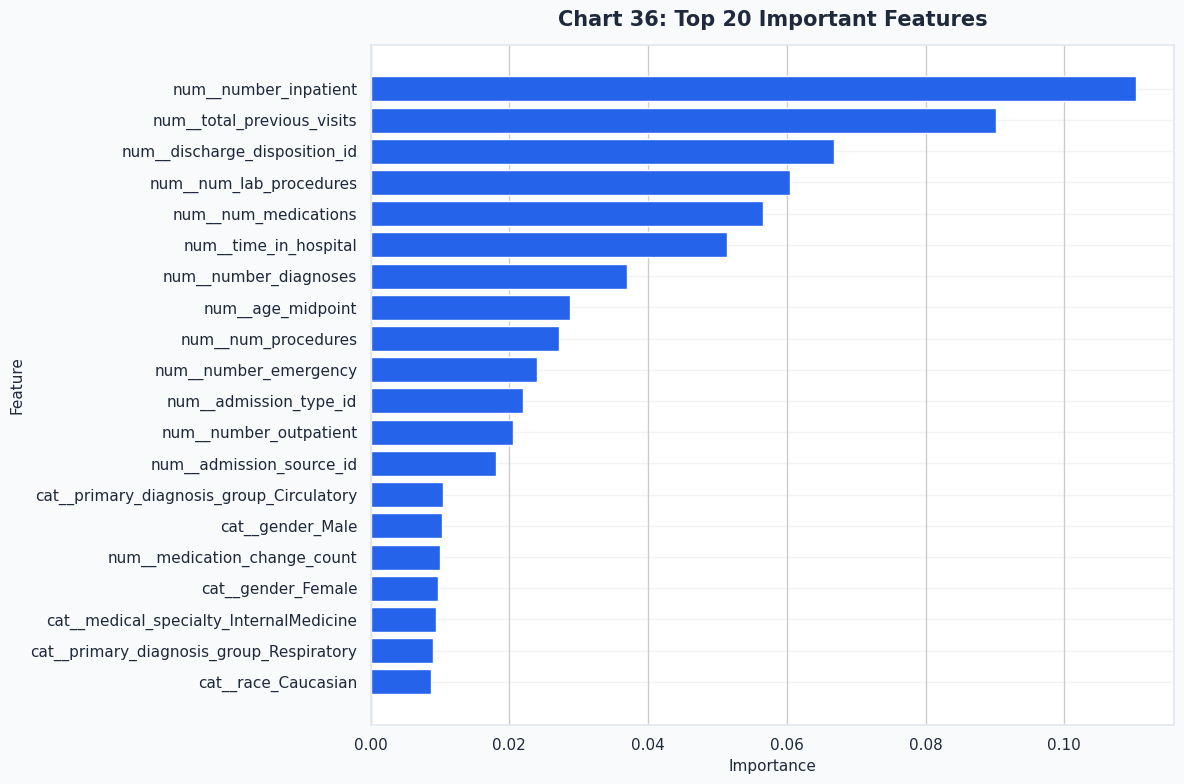

,Feature,Importance
9,num__number_inpatient,0.110306
12,num__total_previous_visits,0.090114
1,num__discharge_disposition_id,0.066830
4,num__num_lab_procedures,0.060510
6,num__num_medications,0.056604
3,num__time_in_hospital,0.051358
10,num__number_diagnoses,0.036948
11,num__age_midpoint,0.028737
5,num__num_procedures,0.027157
8,num__number_emergency,0.024040


In [68]:
# ============================================================
# 16. CHART 36: FEATURE IMPORTANCE OR COEFFICIENTS
# ============================================================

# Extract transformed feature names
try:
    feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
except Exception:
    feature_names = np.array([f'feature_{i}' for i in range(best_model.named_steps['preprocessor'].transform(X_train.iloc[:1]).shape[1])])

classifier = best_model.named_steps['classifier']
importance_df = None

if hasattr(classifier, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': classifier.feature_importances_
    }).sort_values('Importance', ascending=False).head(20)
elif hasattr(classifier, 'coef_'):
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': np.abs(classifier.coef_[0])
    }).sort_values('Importance', ascending=False).head(20)

if importance_df is not None:
    plt.figure(figsize=(12, 8))
    plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1], color=THEME['primary'])
    finish_plot('Chart 36: Top 20 Important Features', 'Importance', 'Feature')
    display(importance_df)
else:
    print('Feature importance is not available for this model.')

# Final Conclusion

This project successfully completed a full data science workflow using an authentic non-Kaggle dataset from the UCI Machine Learning Repository. The dataset contains more than one lac rows and more than thirty columns, so it satisfies the project requirements.

Main work completed:

1. Loaded an authentic healthcare dataset from the web.  
2. Performed dataset introduction and source referencing.  
3. Checked rows, columns, data types, missing values, and duplicates.  
4. Cleaned missing values and invalid entries.  
5. Created new useful features such as age midpoint, total previous visits, medication change count, and primary diagnosis group.  
6. Added before-cleaning and after-cleaning data quality analysis.  
7. Created 36 total charts, including before-cleaning charts, after-cleaning charts, relationship charts, model comparison chart, confusion matrix, and feature importance chart.  
8. Answered multiple data science questions using code.  
9. Built and compared multiple machine learning models.  
10. Evaluated the best model using accuracy, precision, recall, F1-score, classification report, and confusion matrix.

The final model predicts whether a diabetic patient is likely to be readmitted within 30 days. This type of project is useful in healthcare analytics because early readmission prediction can help hospitals identify high-risk patients and improve patient care planning.